### Data Understanding and Exploration

In [2]:
import pandas as pd

In [3]:
# Read in all CSV files and print out the number of rows and columns in each file
base_path = 'mhn predictive dataset/MHN_Dataset/'

df_admin = pd.read_csv(base_path + 'admissions.csv')
df_dic = pd.read_csv(base_path + 'data_dictionary.csv')
df_diagnoses = pd.read_csv(base_path + 'diagnoses.csv')
df_edvisit = pd.read_csv(base_path + 'ed_visits.csv')
df_lab = pd.read_csv(base_path + 'lab_results.csv')
df_med = pd.read_csv(base_path + 'medications.csv')
df_patient = pd.read_csv(base_path + 'patients.csv')
df_readmission = pd.read_csv(base_path + 'readmissions.csv')
df_vitals = pd.read_csv(base_path + 'vitals.csv')

dataframes = {
    'admissions':   df_admin,
    'data_dictionary': df_dic,
    'diagnoses':    df_diagnoses,
    'ed_visits':    df_edvisit,
    'lab_results':  df_lab,
    'medications':  df_med,
    'patients':     df_patient,
    'readmissions': df_readmission,
    'vitals':       df_vitals,
}

for name, df in dataframes.items():
    print(f"\n{name}: {len(df)} rows, {len(df.columns)} columns")
    print(f"  Columns: {list(df.columns)}")



admissions: 8500 rows, 22 columns
  Columns: ['admission_id', 'patient_id', 'admission_date', 'discharge_date', 'length_of_stay_days', 'admission_type', 'admission_source', 'hospital', 'ward', 'primary_diagnosis_icd', 'primary_diagnosis_desc', 'drg_code', 'icu_admitted', 'icu_days', 'surgery_performed', 'num_procedures', 'attending_physician_id', 'discharge_disposition', 'total_charges_usd', 'insurance_paid_usd', 'readmitted_within_30d', 'readmission_reason']

data_dictionary: 21 rows, 4 columns
  Columns: ['table', 'column', 'dtype', 'description']

diagnoses: 29648 rows, 7 columns
  Columns: ['diagnosis_id', 'admission_id', 'patient_id', 'icd10_code', 'description', 'diagnosis_rank', 'poa_flag']

ed_visits: 6000 rows, 22 columns
  Columns: ['ed_visit_id', 'patient_id', 'arrival_datetime', 'departure_datetime', 'triage_level', 'triage_category', 'chief_complaint', 'day_of_week', 'hour_of_arrival', 'month', 'season', 'wait_time_minutes', 'door_to_doctor_min', 'ed_los_minutes', 'imagin

In [4]:
df_admin.head()

,admission_id,patient_id,admission_date,discharge_date,length_of_stay_days,admission_type,admission_source,hospital,ward,primary_diagnosis_icd,...,icu_admitted,icu_days,surgery_performed,num_procedures,attending_physician_id,discharge_disposition,total_charges_usd,insurance_paid_usd,readmitted_within_30d,readmission_reason
0,ADM-0000001,PAT-004458,2022-10-03,2022-10-12,9,Emergency,Physician Referral,MHN Cambridge,Geriatrics,N18.3,...,1,3,1,2,MD-977,Home with Home Health,32669.87,12937.91,0,NaN
1,ADM-0000002,PAT-001044,2023-06-24,2023-06-30,6,Urgent,Transfer,MHN Quincy,Cardiology,I10,...,0,0,0,4,MD-974,Rehab Facility,12853.73,6688.40,0,NaN
2,ADM-0000003,PAT-000197,2024-07-16,2024-07-19,3,Observation,Transfer,MHN Fenway,ICU,I21.9,...,0,0,1,6,MD-355,Home,15034.81,3603.22,0,NaN
3,ADM-0000004,PAT-001374,2020-06-23,2020-06-29,6,Emergency,Direct Admission,MHN Cambridge,Orthopedics,I63.9,...,0,0,1,1,MD-153,Skilled Nursing Facility,45572.71,10745.79,0,NaN
4,ADM-0000005,PAT-004116,2020-07-13,2020-07-17,4,Elective,Physician Referral,MHN Fenway,Respiratory,S72.001,...,1,3,0,2,MD-720,Home with Home Health,9312.46,8516.85,1,New condition


In [5]:
df_dic.head(24)

,table,column,dtype,description
0,patients,patient_id,STRING,Unique patient identifier (PAT-XXXXXX)
1,patients,mrn,STRING,Medical Record Number
2,patients,age,INT,Age in years at time of dataset extraction
3,patients,charlson_comorbidity_index,INT,Simplified CCI — higher = greater mortality risk
4,patients,social_support_score,INT,1–10 score; low score = high readmission risk
5,patients,num_prior_admissions,INT,Historical inpatient admissions count
6,admissions,readmitted_within_30d,INT,TARGET: 1 = readmitted within 30 days of disch...
7,admissions,length_of_stay_days,INT,LOS in days; key predictor
8,admissions,icu_admitted,INT,1 = patient required ICU during this admission
9,admissions,total_charges_usd,FLOAT,Total billed charges in USD


In [6]:
df_admin.head()

,admission_id,patient_id,admission_date,discharge_date,length_of_stay_days,admission_type,admission_source,hospital,ward,primary_diagnosis_icd,...,icu_admitted,icu_days,surgery_performed,num_procedures,attending_physician_id,discharge_disposition,total_charges_usd,insurance_paid_usd,readmitted_within_30d,readmission_reason
0,ADM-0000001,PAT-004458,2022-10-03,2022-10-12,9,Emergency,Physician Referral,MHN Cambridge,Geriatrics,N18.3,...,1,3,1,2,MD-977,Home with Home Health,32669.87,12937.91,0,NaN
1,ADM-0000002,PAT-001044,2023-06-24,2023-06-30,6,Urgent,Transfer,MHN Quincy,Cardiology,I10,...,0,0,0,4,MD-974,Rehab Facility,12853.73,6688.40,0,NaN
2,ADM-0000003,PAT-000197,2024-07-16,2024-07-19,3,Observation,Transfer,MHN Fenway,ICU,I21.9,...,0,0,1,6,MD-355,Home,15034.81,3603.22,0,NaN
3,ADM-0000004,PAT-001374,2020-06-23,2020-06-29,6,Emergency,Direct Admission,MHN Cambridge,Orthopedics,I63.9,...,0,0,1,1,MD-153,Skilled Nursing Facility,45572.71,10745.79,0,NaN
4,ADM-0000005,PAT-004116,2020-07-13,2020-07-17,4,Elective,Physician Referral,MHN Fenway,Respiratory,S72.001,...,1,3,0,2,MD-720,Home with Home Health,9312.46,8516.85,1,New condition


In [7]:
df_diagnoses.head()

,diagnosis_id,admission_id,patient_id,icd10_code,description,diagnosis_rank,poa_flag
0,DX-00000001,ADM-0000001,PAT-004458,J18.9,Pneumonia,2,Y
1,DX-00000002,ADM-0000001,PAT-004458,F32.9,Depression,3,W
2,DX-00000003,ADM-0000001,PAT-004458,M19.90,Osteoarthritis,4,N
3,DX-00000004,ADM-0000001,PAT-004458,G47.33,Obstructive sleep apnoea,5,N
4,DX-00000005,ADM-0000001,PAT-004458,Z79.4,Long-term insulin use,6,N


In [8]:
df_edvisit.head()

,ed_visit_id,patient_id,arrival_datetime,departure_datetime,triage_level,triage_category,chief_complaint,day_of_week,hour_of_arrival,month,...,door_to_doctor_min,ed_los_minutes,imaging_ordered,labs_ordered,iv_access,disposition,admitted_from_ed,left_ama,attending_ed_md,hospital
0,ED-0000001,PAT-004656,2022-11-07 00:00,2022-11-07 09:21,3,Urgent,Drug overdose,Monday,0,11,...,172,561,0,1,1,Admitted,0,0,ED-MD-10,MHN Boston General
1,ED-0000002,PAT-004065,2024-06-23 00:00,2024-06-23 02:45,1,Resuscitation,Leg swelling,Sunday,0,6,...,28,165,1,0,0,Discharged Home,1,0,ED-MD-40,MHN Boston General
2,ED-0000003,PAT-003922,2020-12-07 00:00,2020-12-07 06:25,5,Non-Urgent,Hypertensive urgency,Monday,0,12,...,11,385,0,1,0,Discharged Home,1,0,ED-MD-33,MHN Roxbury Community
3,ED-0000004,PAT-001788,2020-12-14 00:00,2020-12-14 04:07,4,Less Urgent,Leg swelling,Monday,0,12,...,5,247,0,0,1,Discharged Home,0,0,ED-MD-36,MHN Boston General
4,ED-0000005,PAT-004741,2021-08-19 00:00,2021-08-19 01:35,3,Urgent,Altered mental status,Thursday,0,8,...,65,95,0,1,1,Admitted,0,0,ED-MD-25,MHN Jamaica Plain


In [9]:
df_vitals.head()

,vital_id,admission_id,patient_id,measured_at,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature_c,spo2_percent,gcs_score,news2_score,pain_score,weight_kg,height_cm
0,VIT-00000001,ADM-0000001,PAT-004458,2022-10-03 00:00,113.4,48.6,100.0,14.0,37.2,94.0,15,1,3,62.7,166.6
1,VIT-00000002,ADM-0000001,PAT-004458,2022-10-04 12:00,147.8,86.2,88.0,16.0,37.9,98.8,15,0,1,40.0,158.5
2,VIT-00000003,ADM-0000001,PAT-004458,2022-10-06 00:00,88.7,83.4,78.0,17.0,37.2,97.9,13,6,9,93.8,181.8
3,VIT-00000004,ADM-0000001,PAT-004458,2022-10-07 12:00,126.8,81.6,97.0,16.0,38.1,98.5,15,1,6,95.4,170.0
4,VIT-00000005,ADM-0000001,PAT-004458,2022-10-09 00:00,120.6,73.3,87.0,15.0,37.4,93.2,12,4,8,96.8,171.9


In [10]:
df_readmission.head()

,readmission_id,original_admission_id,patient_id,original_discharge_date,readmission_date,days_to_readmission,readmission_type,readmission_reason,same_diagnosis,planned_readmission,avoided_if_discharged_better
0,RA-000001,ADM-0000005,PAT-004116,2020-07-17,2020-07-31,14,Urgent,New condition,1,0,0
1,RA-000002,ADM-0000006,PAT-002464,2022-09-03,2022-09-24,21,Emergency,Infection,0,1,0
2,RA-000003,ADM-0000019,PAT-001571,2022-01-15,2022-01-26,11,Emergency,New condition,0,0,1
3,RA-000004,ADM-0000020,PAT-004863,2021-03-07,2021-03-27,20,Emergency,Infection,1,0,1
4,RA-000005,ADM-0000032,PAT-003528,2020-10-12,2020-10-26,14,Emergency,Complication,1,1,1


In [11]:
df_patient.head()

,patient_id,mrn,first_name,last_name,date_of_birth,age,gender,ethnicity,insurance_type,zip_code,...,has_obesity,has_cancer,charlson_comorbidity_index,num_prior_admissions,num_prior_ed_visits,smoking_status,alcohol_use,language_preference,social_support_score,registered_date
0,PAT-000001,MRN-25962676,Daniel,Ali,1977-01-01,47,Male,White,Uninsured,2118,...,1,0,1,1,2,Never,NaN,English,10,2020-06-06
1,PAT-000002,MRN-33408016,Linda,Nguyen,2006-01-01,18,Female,White,Private Insurance,2130,...,0,0,0,1,0,Former,NaN,Other,2,2015-07-31
2,PAT-000003,MRN-12058920,Mary,Walker,1974-01-01,50,Female,Asian,Self-Pay,2118,...,1,0,0,6,2,Never,Heavy,English,2,2019-10-04
3,PAT-000004,MRN-73721224,Ana,Kim,1950-01-01,74,Female,White,Medicare,2130,...,0,0,1,0,0,Former,Heavy,Mandarin,10,2018-07-20
4,PAT-000005,MRN-62709314,Thomas,Clark,1957-01-01,67,Male,White,Medicare,2115,...,0,0,5,2,5,Former,NaN,English,6,2022-09-27


In [12]:
df_patient['alcohol_use'].value_counts()

alcohol_use
Moderate    1769
Heavy        489
Name: count, dtype: int64

In [13]:
df_patient['alcohol_use'].isnull().sum()

np.int64(2742)

In [14]:
df_readmission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1813 entries, 0 to 1812
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   readmission_id                1813 non-null   object
 1   original_admission_id         1813 non-null   object
 2   patient_id                    1813 non-null   object
 3   original_discharge_date       1813 non-null   object
 4   readmission_date              1813 non-null   object
 5   days_to_readmission           1813 non-null   int64 
 6   readmission_type              1813 non-null   object
 7   readmission_reason            1813 non-null   object
 8   same_diagnosis                1813 non-null   int64 
 9   planned_readmission           1813 non-null   int64 
 10  avoided_if_discharged_better  1813 non-null   int64 
dtypes: int64(4), object(7)
memory usage: 155.9+ KB


In [15]:
master_df = pd.read_csv('model/master_dataset.csv')

In [16]:
master_df.head()

,admission_id,patient_id,admission_date,discharge_date,length_of_stay_days,admission_type,admission_source,hospital,ward,primary_diagnosis_icd,...,registered_date,age_group,total_comorbidities,is_high_comorbidity,is_high_utiliser,low_social_support,num_ed_visits,num_ed_admissions,avg_ed_wait_minutes,avg_ed_los_minutes
0,ADM-0000001,PAT-004458,2022-10-03,2022-10-12,9,Emergency,Physician Referral,MHN Cambridge,Geriatrics,N18.3,...,2018-03-28,50-64,5,1,1,0,0.0,0.0,NaN,NaN
1,ADM-0000002,PAT-001044,2023-06-24,2023-06-30,6,Urgent,Transfer,MHN Quincy,Cardiology,I10,...,2020-07-22,80+,4,1,1,0,1.0,0.0,43.0,177.0
2,ADM-0000003,PAT-000197,2024-07-16,2024-07-19,3,Observation,Transfer,MHN Fenway,ICU,I21.9,...,2020-12-03,65-79,2,1,0,0,0.0,0.0,NaN,NaN
3,ADM-0000004,PAT-001374,2020-06-23,2020-06-29,6,Emergency,Direct Admission,MHN Cambridge,Orthopedics,I63.9,...,2021-11-28,50-64,4,1,1,0,0.0,0.0,NaN,NaN
4,ADM-0000005,PAT-004116,2020-07-13,2020-07-17,4,Elective,Physician Referral,MHN Fenway,Respiratory,S72.001,...,2017-09-04,50-64,1,0,0,0,0.0,0.0,NaN,NaN


In [17]:
master_df.columns.tolist()

['admission_id',
 'patient_id',
 'admission_date',
 'discharge_date',
 'length_of_stay_days',
 'admission_type',
 'admission_source',
 'hospital',
 'ward',
 'primary_diagnosis_icd',
 'primary_diagnosis_desc',
 'drg_code',
 'icu_admitted',
 'icu_days',
 'surgery_performed',
 'num_procedures',
 'attending_physician_id',
 'discharge_disposition',
 'total_charges_usd',
 'insurance_paid_usd',
 'readmitted_within_30d',
 'readmission_reason',
 'admission_year',
 'admission_month',
 'admission_dayofweek',
 'is_weekend_admission',
 'cost_per_day',
 'out_of_pocket_cost',
 'insurance_coverage_ratio',
 'icu_ratio',
 'had_icu_stay',
 'systolic_bp_mean',
 'systolic_bp_min',
 'systolic_bp_max',
 'systolic_bp_std',
 'diastolic_bp_mean',
 'diastolic_bp_min',
 'diastolic_bp_max',
 'diastolic_bp_std',
 'heart_rate_mean',
 'heart_rate_min',
 'heart_rate_max',
 'heart_rate_std',
 'respiratory_rate_mean',
 'respiratory_rate_min',
 'respiratory_rate_max',
 'respiratory_rate_std',
 'temperature_c_mean',
 'tem

In [18]:
#print only the columns with missing values and the number of missing values in each column
master_df.isnull().sum()[master_df.isnull().sum() > 0]	

readmission_reason     6687
avg_ed_wait_minutes    3165
avg_ed_los_minutes     3165
dtype: int64

In [19]:
master_df['readmitted_within_30d'].value_counts()

readmitted_within_30d
0    6687
1    1813
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)
Full EDA on each dataset: **Univariate → Bivariate → Multivariate**

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Convenience helpers
def plot_numeric_univariate(df, cols, title):
    n = len(cols)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
    if n == 1:
        axes = [axes]
    for ax_pair, col in zip(axes, cols):
        df[col].dropna().plot.hist(bins=40, ax=ax_pair[0], edgecolor='white')
        ax_pair[0].set_title(f'{col} — Distribution')
        ax_pair[0].set_xlabel(col)
        df[col].dropna().plot.box(ax=ax_pair[1], vert=False)
        ax_pair[1].set_title(f'{col} — Box Plot')
    fig.suptitle(title, fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

def plot_categorical_univariate(df, cols, title, top_n=15):
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        vc = df[col].value_counts().head(top_n)
        vc.plot.bar(ax=ax, edgecolor='white')
        ax.set_title(f'{col}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)
    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()

def missing_summary(df, name):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    pct  = (miss / len(df) * 100).round(2)
    print(f"\n{'='*50}")
    print(f"  {name.upper()} — shape: {df.shape}")
    print(f"{'='*50}")
    if miss.empty:
        print("  No missing values.")
    else:
        print(pd.DataFrame({'Missing': miss, 'Pct %': pct}).to_string())
    print(f"\n  Duplicate rows: {df.duplicated().sum():,}")
    print(df.dtypes.to_string())

print("Libraries loaded.")

Libraries loaded.


---
## 1. Admissions
**Key columns:** `admission_id`, `patient_id`, `admission_date`, `discharge_date`, `length_of_stay_days`, `total_charges_usd`, `insurance_paid_usd`, `icu_days`, `readmitted_within_30d`, `admission_type`, `admission_source`, `discharge_disposition`

In [22]:
# --- Admissions: Overview ---
missing_summary(df_admin, 'admissions')
df_admin.describe().T


  ADMISSIONS — shape: (8500, 22)
                    Missing  Pct %
readmission_reason     6687  78.67

  Duplicate rows: 0
admission_id               object
patient_id                 object
admission_date             object
discharge_date             object
length_of_stay_days         int64
admission_type             object
admission_source           object
hospital                   object
ward                       object
primary_diagnosis_icd      object
primary_diagnosis_desc     object
drg_code                    int64
icu_admitted                int64
icu_days                    int64
surgery_performed           int64
num_procedures              int64
attending_physician_id     object
discharge_disposition      object
total_charges_usd         float64
insurance_paid_usd        float64
readmitted_within_30d       int64
readmission_reason         object


,count,mean,std,min,25%,50%,75%,max
length_of_stay_days,8500.0,5.844588,4.897390,1.00,3.0000,4.000,8.0000,45.00
drg_code,8500.0,545.501882,258.046096,100.00,320.0000,549.000,770.0000,998.00
icu_admitted,8500.0,0.227176,0.419032,0.00,0.0000,0.000,0.0000,1.00
icu_days,8500.0,1.342941,2.904353,0.00,0.0000,0.000,0.0000,11.00
surgery_performed,8500.0,0.359059,0.479753,0.00,0.0000,0.000,1.0000,1.00
num_procedures,8500.0,3.464353,2.283120,0.00,1.0000,3.000,5.0000,7.00
total_charges_usd,8500.0,18295.259959,17154.900708,729.50,7881.4350,13395.725,22581.5575,273095.38
insurance_paid_usd,8500.0,11112.377209,10478.046621,421.14,4731.2925,8137.515,13778.2325,173890.03
readmitted_within_30d,8500.0,0.213294,0.409658,0.00,0.0000,0.000,0.0000,1.00


### 1a. Admissions — Univariate Analysis

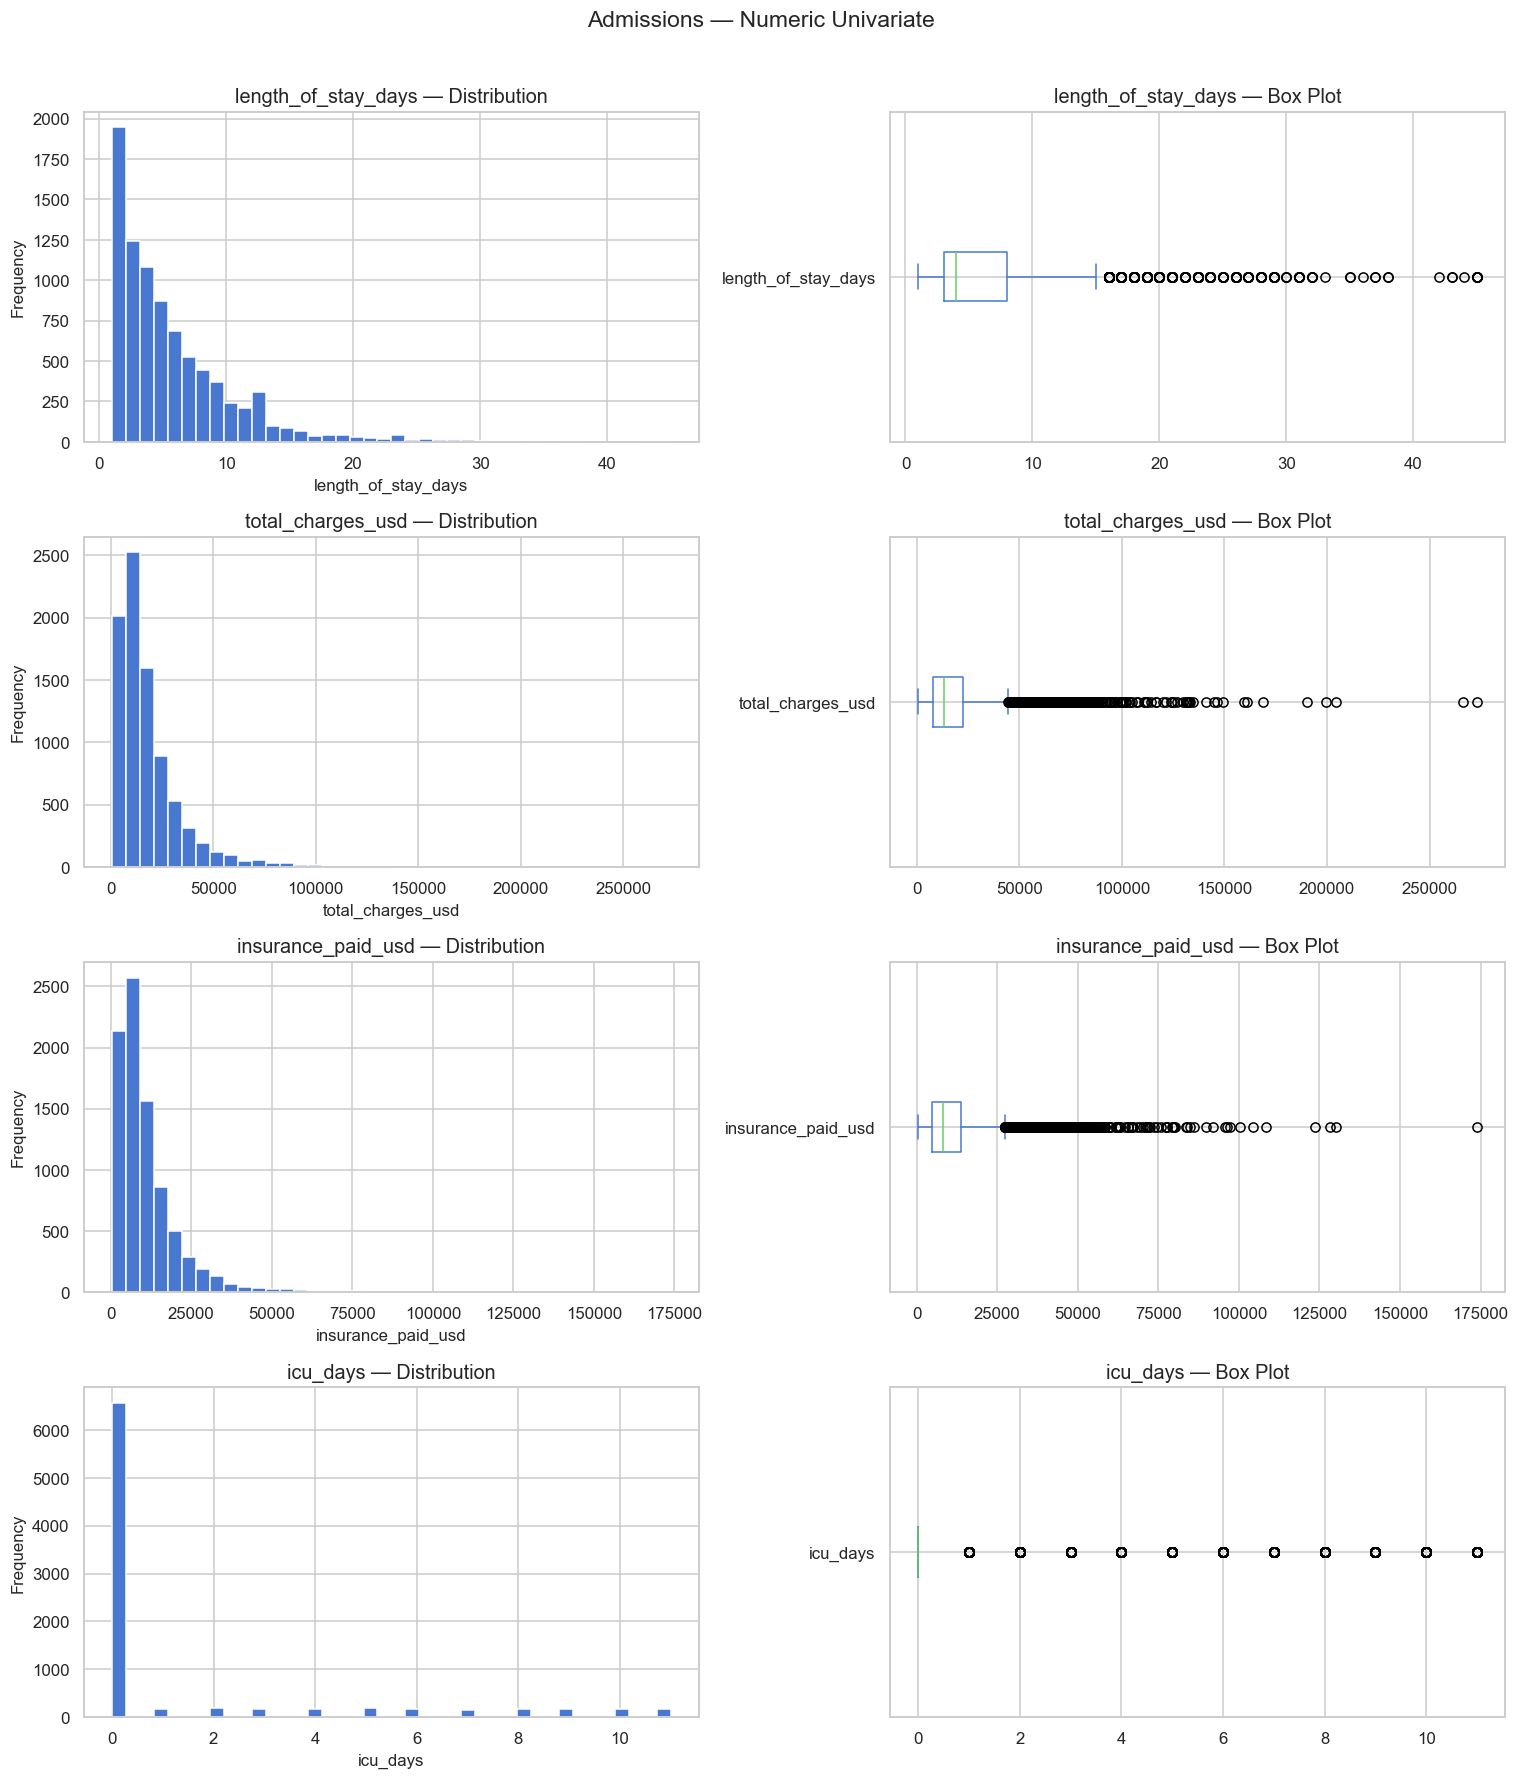

In [23]:
# Numeric distributions
num_cols = ['length_of_stay_days', 'total_charges_usd', 'insurance_paid_usd', 'icu_days']
plot_numeric_univariate(df_admin, num_cols, 'Admissions — Numeric Univariate')

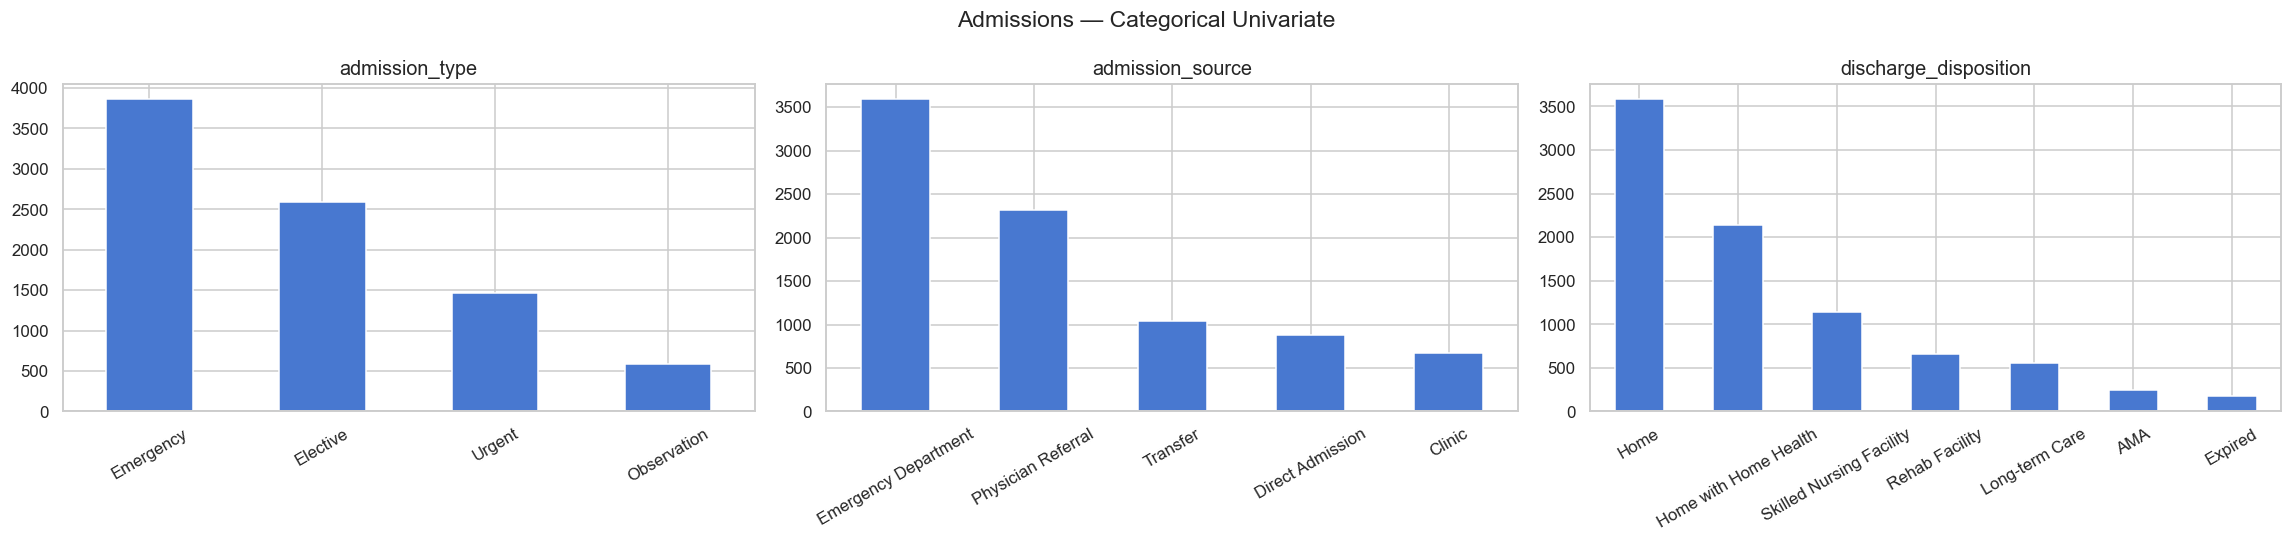

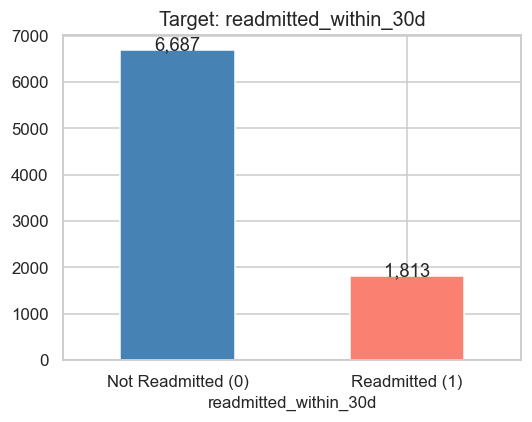

readmitted_within_30d
0    78.67
1    21.33


In [24]:
# Categorical distributions
cat_cols = ['admission_type', 'admission_source', 'discharge_disposition']
plot_categorical_univariate(df_admin, cat_cols, 'Admissions — Categorical Univariate')

# Target variable
fig, ax = plt.subplots(figsize=(5, 4))
df_admin['readmitted_within_30d'].value_counts().plot.bar(ax=ax, edgecolor='white', color=['steelblue', 'salmon'])
ax.set_title('Target: readmitted_within_30d')
ax.set_xticklabels(['Not Readmitted (0)', 'Readmitted (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()+10), ha='center')
plt.tight_layout()
plt.show()
print(df_admin['readmitted_within_30d'].value_counts(normalize=True).mul(100).round(2).to_string())

### 1b. Admissions — Bivariate Analysis (vs `readmitted_within_30d`)

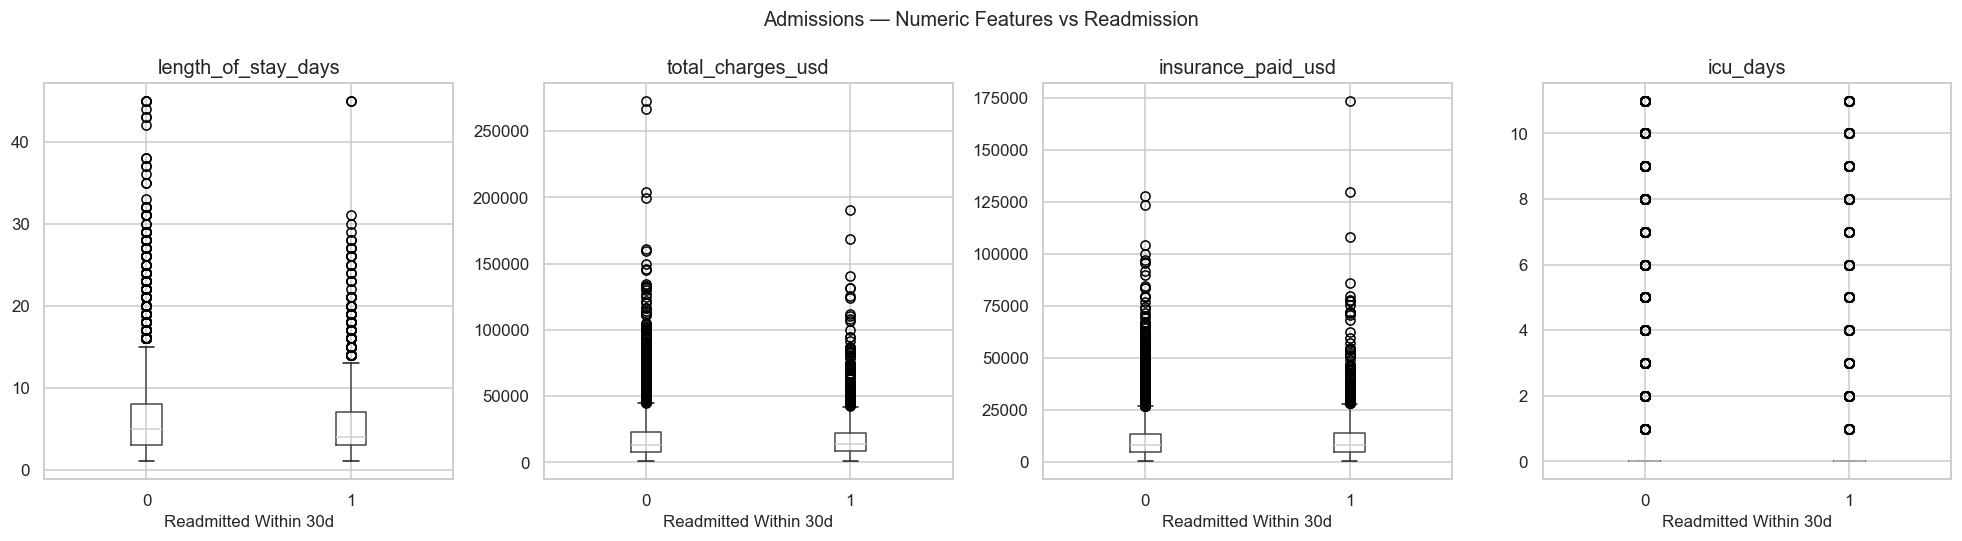

                       length_of_stay_days  total_charges_usd  \
readmitted_within_30d                                           
0                                     5.90           18262.64   
1                                     5.64           18415.59   

                       insurance_paid_usd  icu_days  
readmitted_within_30d                                
0                                11019.69      1.33  
1                                11454.23      1.39  


In [25]:
# Numeric features vs target (box plots)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, ['length_of_stay_days', 'total_charges_usd', 'insurance_paid_usd', 'icu_days']):
    df_admin.boxplot(column=col, by='readmitted_within_30d', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Readmitted Within 30d')
fig.suptitle('Admissions — Numeric Features vs Readmission', fontsize=13)
plt.tight_layout()
plt.show()

# Mean values by readmission status
print(df_admin.groupby('readmitted_within_30d')[
    ['length_of_stay_days', 'total_charges_usd', 'insurance_paid_usd', 'icu_days']
].mean().round(2))

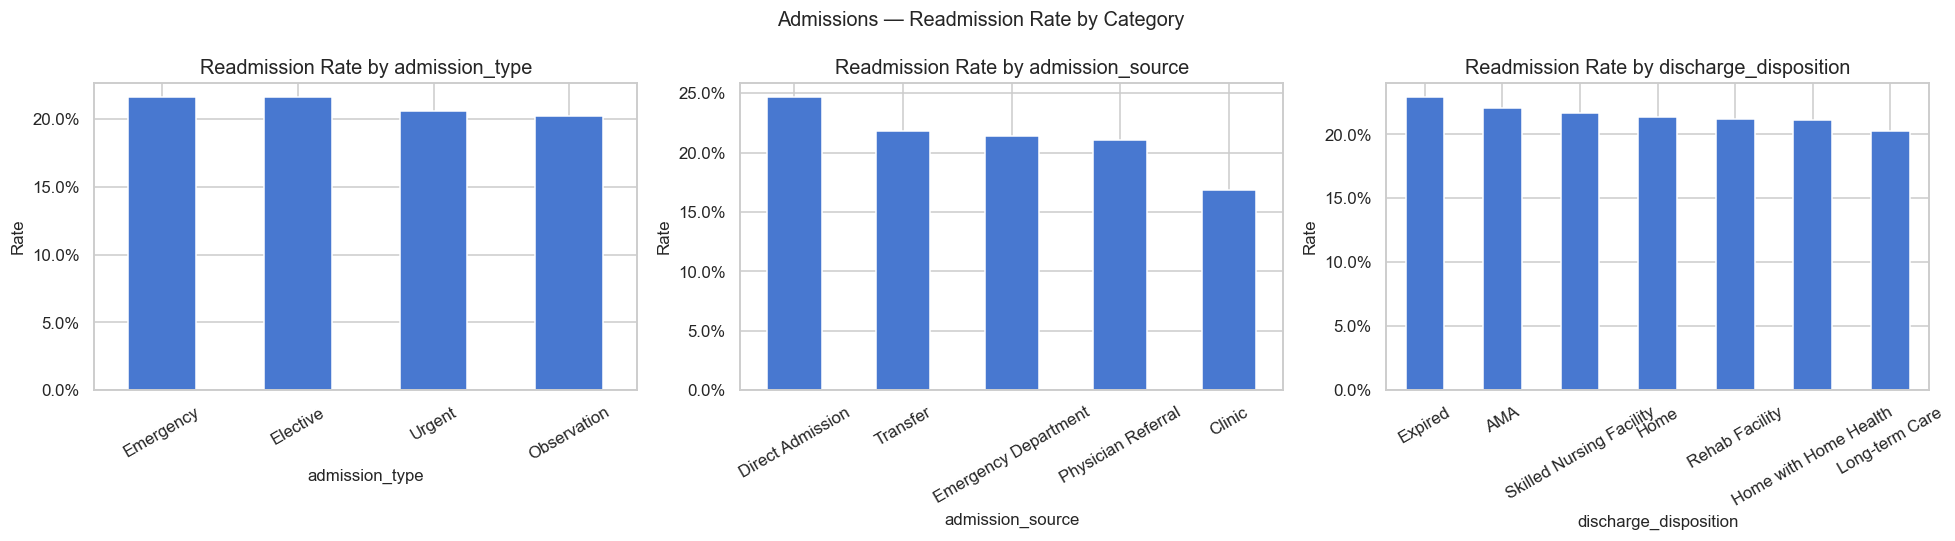

In [26]:
# Readmission rate by categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['admission_type', 'admission_source', 'discharge_disposition']):
    rate = df_admin.groupby(col)['readmitted_within_30d'].mean().sort_values(ascending=False)
    rate.plot.bar(ax=ax, edgecolor='white')
    ax.set_title(f'Readmission Rate by {col}')
    ax.set_ylabel('Rate')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
fig.suptitle('Admissions — Readmission Rate by Category', fontsize=13)
plt.tight_layout()
plt.show()

### 1c. Admissions — Multivariate Analysis

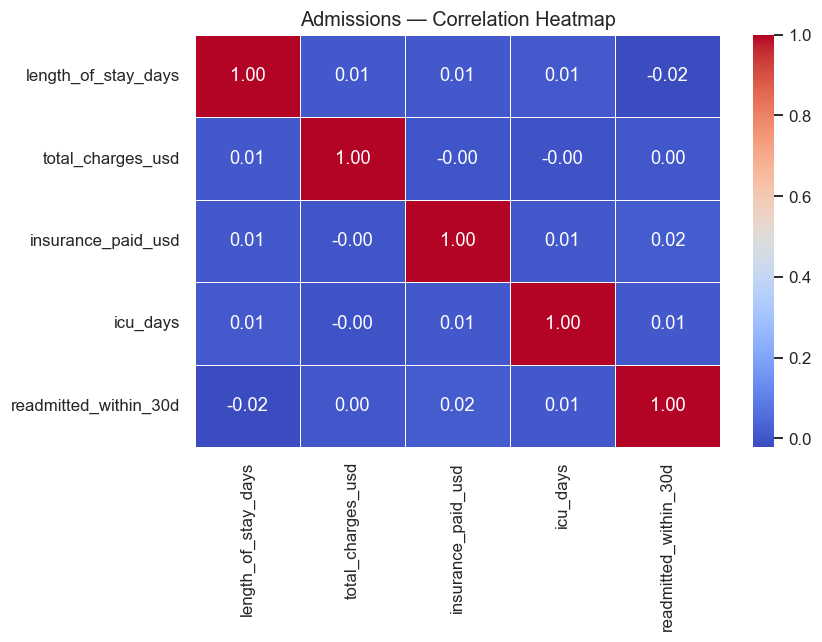

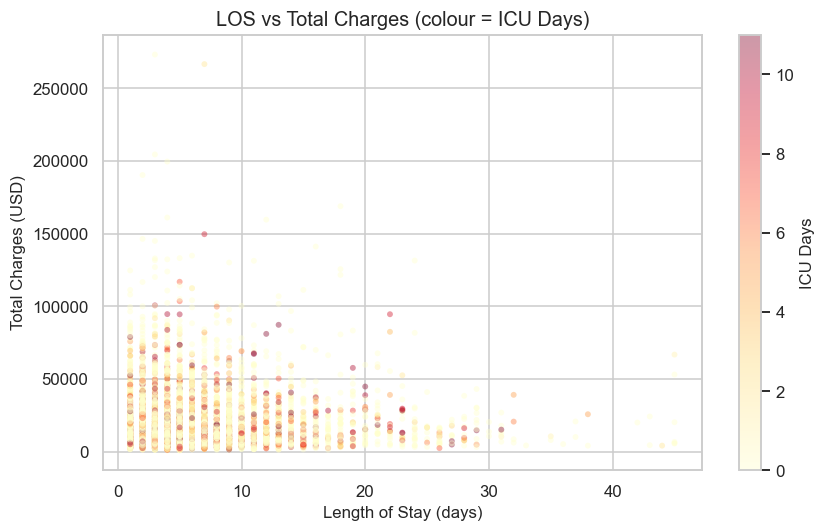

In [27]:
# Correlation heatmap of numeric columns
num_admin = df_admin[['length_of_stay_days', 'total_charges_usd', 'insurance_paid_usd',
                       'icu_days', 'readmitted_within_30d']].copy()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(num_admin.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Admissions — Correlation Heatmap')
plt.tight_layout()
plt.show()

# LOS vs Charges coloured by ICU stay
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df_admin['length_of_stay_days'], df_admin['total_charges_usd'],
    c=df_admin['icu_days'], cmap='YlOrRd', alpha=0.4, edgecolors='none', s=15
)
plt.colorbar(scatter, ax=ax, label='ICU Days')
ax.set_xlabel('Length of Stay (days)')
ax.set_ylabel('Total Charges (USD)')
ax.set_title('LOS vs Total Charges (colour = ICU Days)')
plt.tight_layout()
plt.show()

---
## 2. Patients
**Key columns:** `patient_id`, `age`, `gender`, `ethnicity`, `insurance_type`, `smoking_status`, `alcohol_use`, `charlson_comorbidity_index`, `num_prior_admissions`, `num_prior_ed_visits`, `social_support_score`, comorbidity flags

In [28]:
# --- Patients: Overview ---
missing_summary(df_patient, 'patients')
df_patient.describe().T


  PATIENTS — shape: (5000, 27)
             Missing  Pct %
alcohol_use     2742  54.84

  Duplicate rows: 0
patient_id                    object
mrn                           object
first_name                    object
last_name                     object
date_of_birth                 object
age                            int64
gender                        object
ethnicity                     object
insurance_type                object
zip_code                       int64
primary_hospital              object
has_diabetes                   int64
has_hypertension               int64
has_heart_disease              int64
has_copd                       int64
has_ckd                        int64
has_depression                 int64
has_obesity                    int64
has_cancer                     int64
charlson_comorbidity_index     int64
num_prior_admissions           int64
num_prior_ed_visits            int64
smoking_status                object
alcohol_use                   object
lan

,count,mean,std,min,25%,50%,75%,max
age,5000.0,57.1328,17.722313,18.0,45.0,57.0,70.0,95.0
zip_code,5000.0,2119.9180,8.521209,2101.0,2118.0,2122.0,2127.0,2130.0
has_diabetes,5000.0,0.2592,0.438239,0.0,0.0,0.0,1.0,1.0
has_hypertension,5000.0,0.3708,0.483067,0.0,0.0,0.0,1.0,1.0
has_heart_disease,5000.0,0.1750,0.380005,0.0,0.0,0.0,0.0,1.0
has_copd,5000.0,0.1186,0.323350,0.0,0.0,0.0,0.0,1.0
has_ckd,5000.0,0.1168,0.321214,0.0,0.0,0.0,0.0,1.0
has_depression,5000.0,0.1972,0.397924,0.0,0.0,0.0,0.0,1.0
has_obesity,5000.0,0.3764,0.484531,0.0,0.0,0.0,1.0,1.0
has_cancer,5000.0,0.0680,0.251771,0.0,0.0,0.0,0.0,1.0


### 2a. Patients — Univariate Analysis

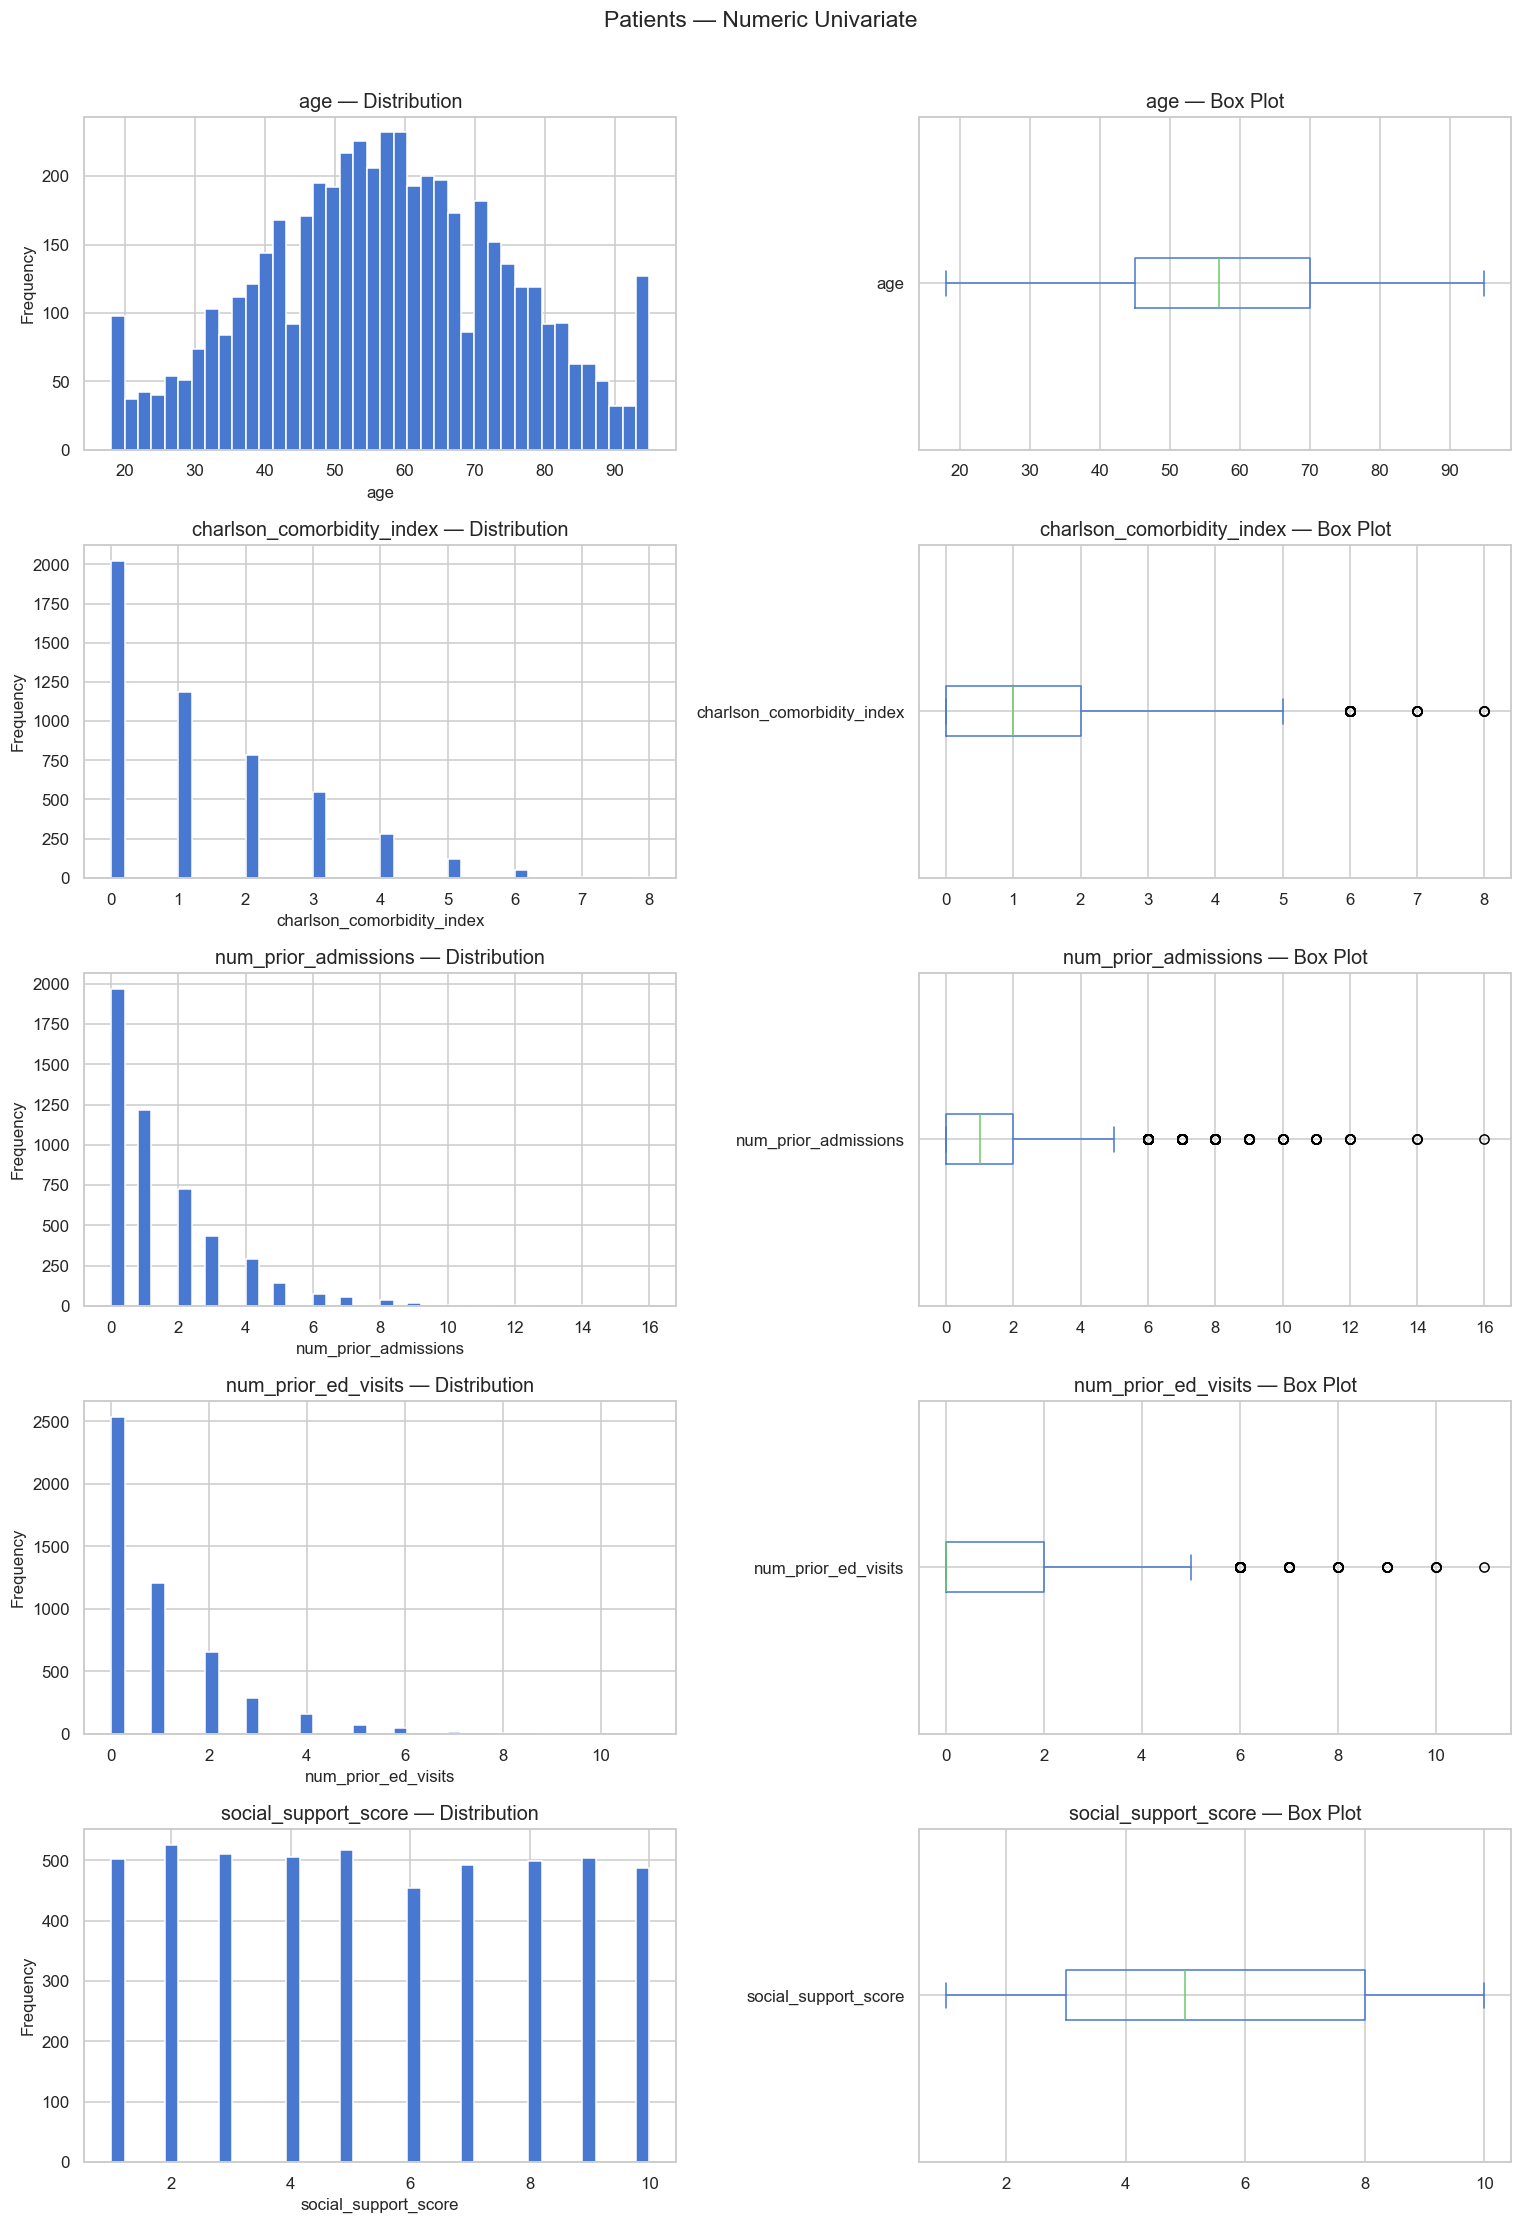

In [29]:
# Numeric
num_cols_pat = ['age', 'charlson_comorbidity_index', 'num_prior_admissions',
                'num_prior_ed_visits', 'social_support_score']
plot_numeric_univariate(df_patient, num_cols_pat, 'Patients — Numeric Univariate')

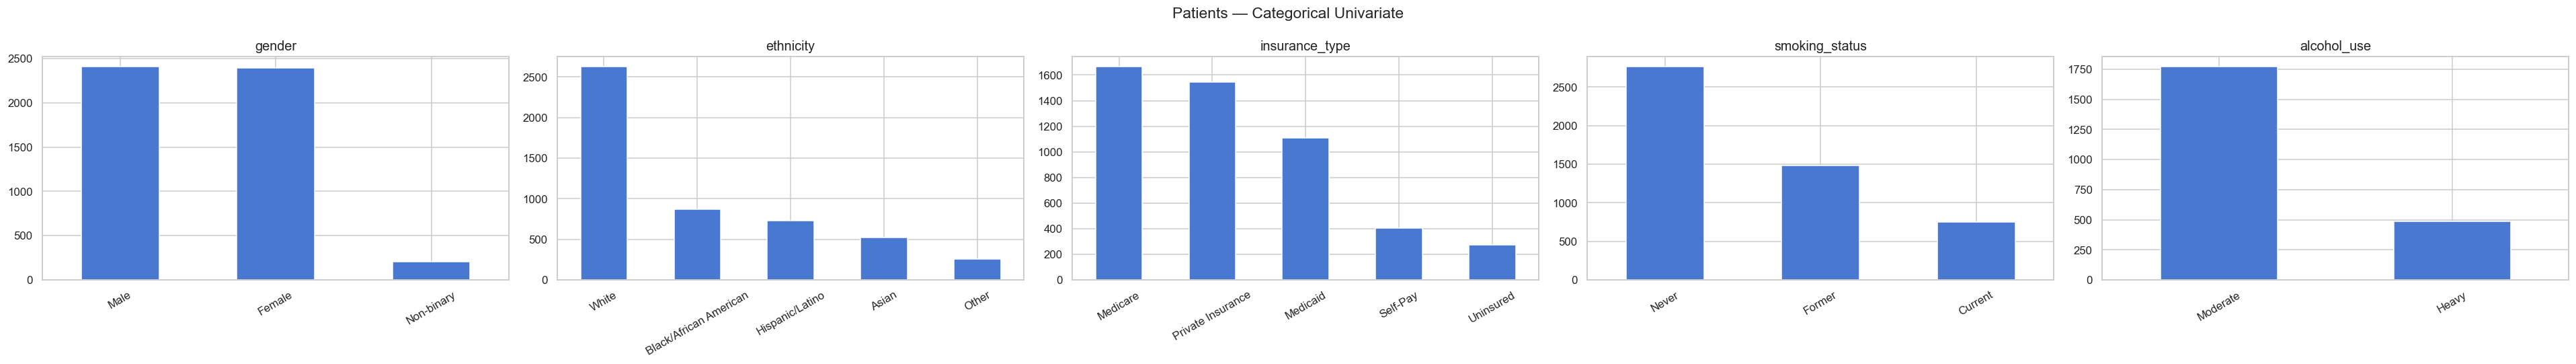

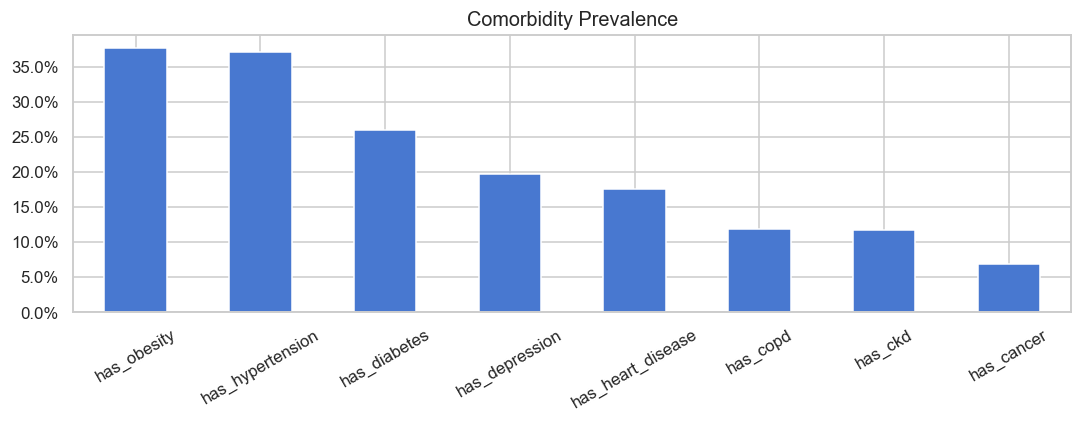

In [30]:
# Categorical
cat_cols_pat = ['gender', 'ethnicity', 'insurance_type', 'smoking_status', 'alcohol_use']
plot_categorical_univariate(df_patient, cat_cols_pat, 'Patients — Categorical Univariate')

# Comorbidity prevalence
comorbidity_cols = ['has_diabetes', 'has_hypertension', 'has_heart_disease',
                    'has_copd', 'has_ckd', 'has_depression', 'has_obesity', 'has_cancer']
prev = df_patient[comorbidity_cols].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
prev.plot.bar(ax=ax, edgecolor='white')
ax.set_title('Comorbidity Prevalence')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 2b. Patients — Bivariate Analysis

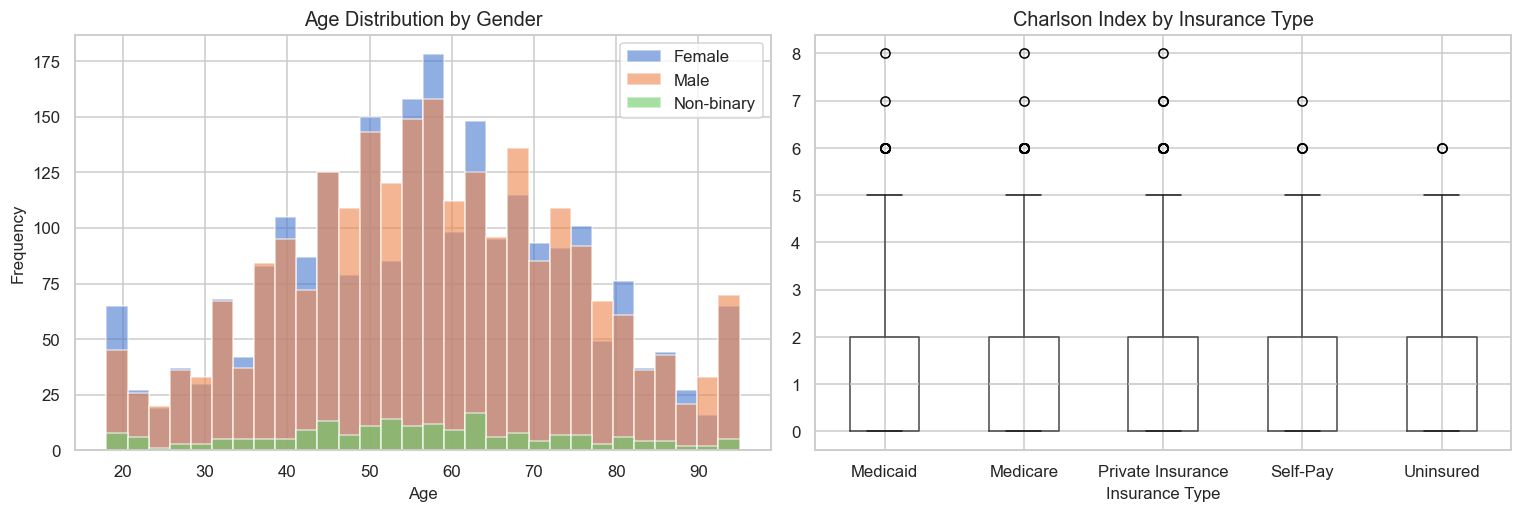

Mean Prior Admissions by Smoking Status:
smoking_status
Never      1.51
Former     1.49
Current    1.45
Name: num_prior_admissions, dtype: float64


In [32]:
# Age distribution by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for gender, grp in df_patient.groupby('gender'):
    grp['age'].plot.hist(bins=30, alpha=0.6, ax=axes[0], label=gender, edgecolor='white')
axes[0].set_title('Age Distribution by Gender')
axes[0].legend()
axes[0].set_xlabel('Age')

# Charlson index by insurance type
df_patient.boxplot(column='charlson_comorbidity_index', by='insurance_type', ax=axes[1])
axes[1].set_title('Charlson Index by Insurance Type')
axes[1].set_xlabel('Insurance Type')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Prior admissions by smoking status
print("Mean Prior Admissions by Smoking Status:")
print(df_patient.groupby('smoking_status')['num_prior_admissions'].mean().sort_values(ascending=False).round(2))

### 2c. Patients — Multivariate Analysis

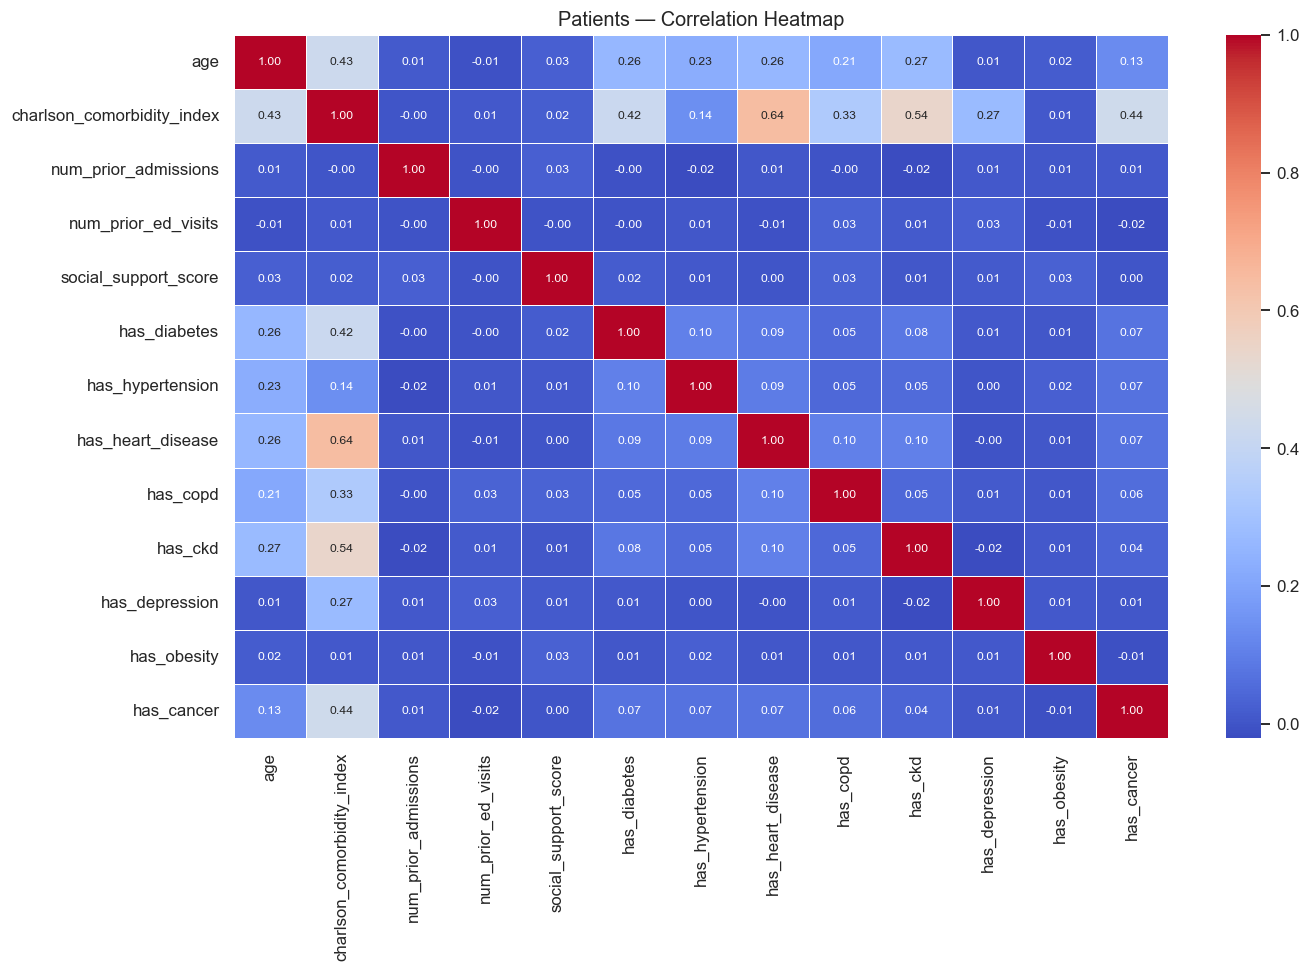

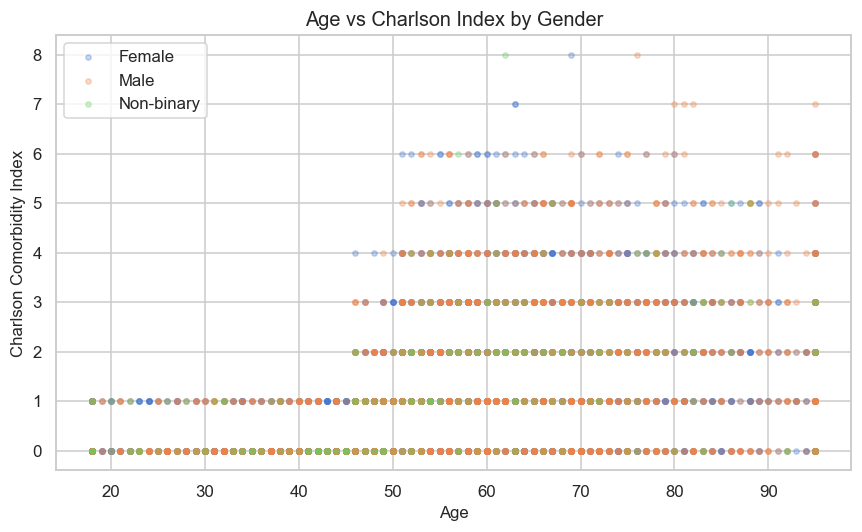

In [33]:
# Correlation heatmap of numeric + comorbidity columns
comorbidity_cols = ['has_diabetes', 'has_hypertension', 'has_heart_disease',
                    'has_copd', 'has_ckd', 'has_depression', 'has_obesity', 'has_cancer']
num_pat_all = df_patient[['age', 'charlson_comorbidity_index', 'num_prior_admissions',
                           'num_prior_ed_visits', 'social_support_score'] + comorbidity_cols]
fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(num_pat_all.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.4, annot_kws={'size': 8})
ax.set_title('Patients — Correlation Heatmap')
plt.tight_layout()
plt.show()

# Age vs Charlson index by gender
fig, ax = plt.subplots(figsize=(8, 5))
for gender, grp in df_patient.groupby('gender'):
    ax.scatter(grp['age'], grp['charlson_comorbidity_index'], label=gender, alpha=0.3, s=12)
ax.set_xlabel('Age')
ax.set_ylabel('Charlson Comorbidity Index')
ax.set_title('Age vs Charlson Index by Gender')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Diagnoses
**Key columns:** `diagnosis_id`, `admission_id`, `icd_code`, `diagnosis_rank`, `poa_flag`

In [34]:
missing_summary(df_diagnoses, 'diagnoses')
df_diagnoses.describe().T


  DIAGNOSES — shape: (29648, 7)
  No missing values.

  Duplicate rows: 0
diagnosis_id      object
admission_id      object
patient_id        object
icd10_code        object
description       object
diagnosis_rank     int64
poa_flag          object


,count,mean,std,min,25%,50%,75%,max
diagnosis_rank,29648.0,3.662743,1.488454,2.0,2.0,3.0,5.0,7.0



## 3. ED Visits
**Key columns:** `ed_visit_id`, `patient_id`, `arrival_datetime`, `departure_datetime`, `wait_time_minutes`, `door_to_doctor_min`, `ed_los_minutes`, `triage_category`, `admitted_from_ed`

In [38]:
missing_summary(df_edvisit, 'ed_visits')
df_edvisit.describe().T


  ED_VISITS — shape: (6000, 22)
  No missing values.

  Duplicate rows: 0
ed_visit_id           object
patient_id            object
arrival_datetime      object
departure_datetime    object
triage_level           int64
triage_category       object
chief_complaint       object
day_of_week           object
hour_of_arrival        int64
month                  int64
season                object
wait_time_minutes      int64
door_to_doctor_min     int64
ed_los_minutes         int64
imaging_ordered        int64
labs_ordered           int64
iv_access              int64
disposition           object
admitted_from_ed       int64
left_ama               int64
attending_ed_md       object
hospital              object


,count,mean,std,min,25%,50%,75%,max
triage_level,6000.0,3.041333,1.003224,1.0,2.0,3.0,4.00,5.0
hour_of_arrival,6000.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0
month,6000.0,6.513167,3.463740,1.0,3.0,7.0,10.00,12.0
wait_time_minutes,6000.0,68.526000,77.299654,0.0,18.0,44.0,91.25,1132.0
door_to_doctor_min,6000.0,68.771667,77.091107,5.0,18.0,44.0,91.25,1132.0
ed_los_minutes,6000.0,308.642000,125.070451,35.0,223.0,302.0,382.25,1412.0
imaging_ordered,6000.0,0.496667,0.500031,0.0,0.0,0.0,1.00,1.0
labs_ordered,6000.0,0.321833,0.467218,0.0,0.0,0.0,1.00,1.0
iv_access,6000.0,0.500000,0.500042,0.0,0.0,0.5,1.00,1.0
admitted_from_ed,6000.0,0.274167,0.446131,0.0,0.0,0.0,1.00,1.0


### 4a. ED Visits — Univariate Analysis

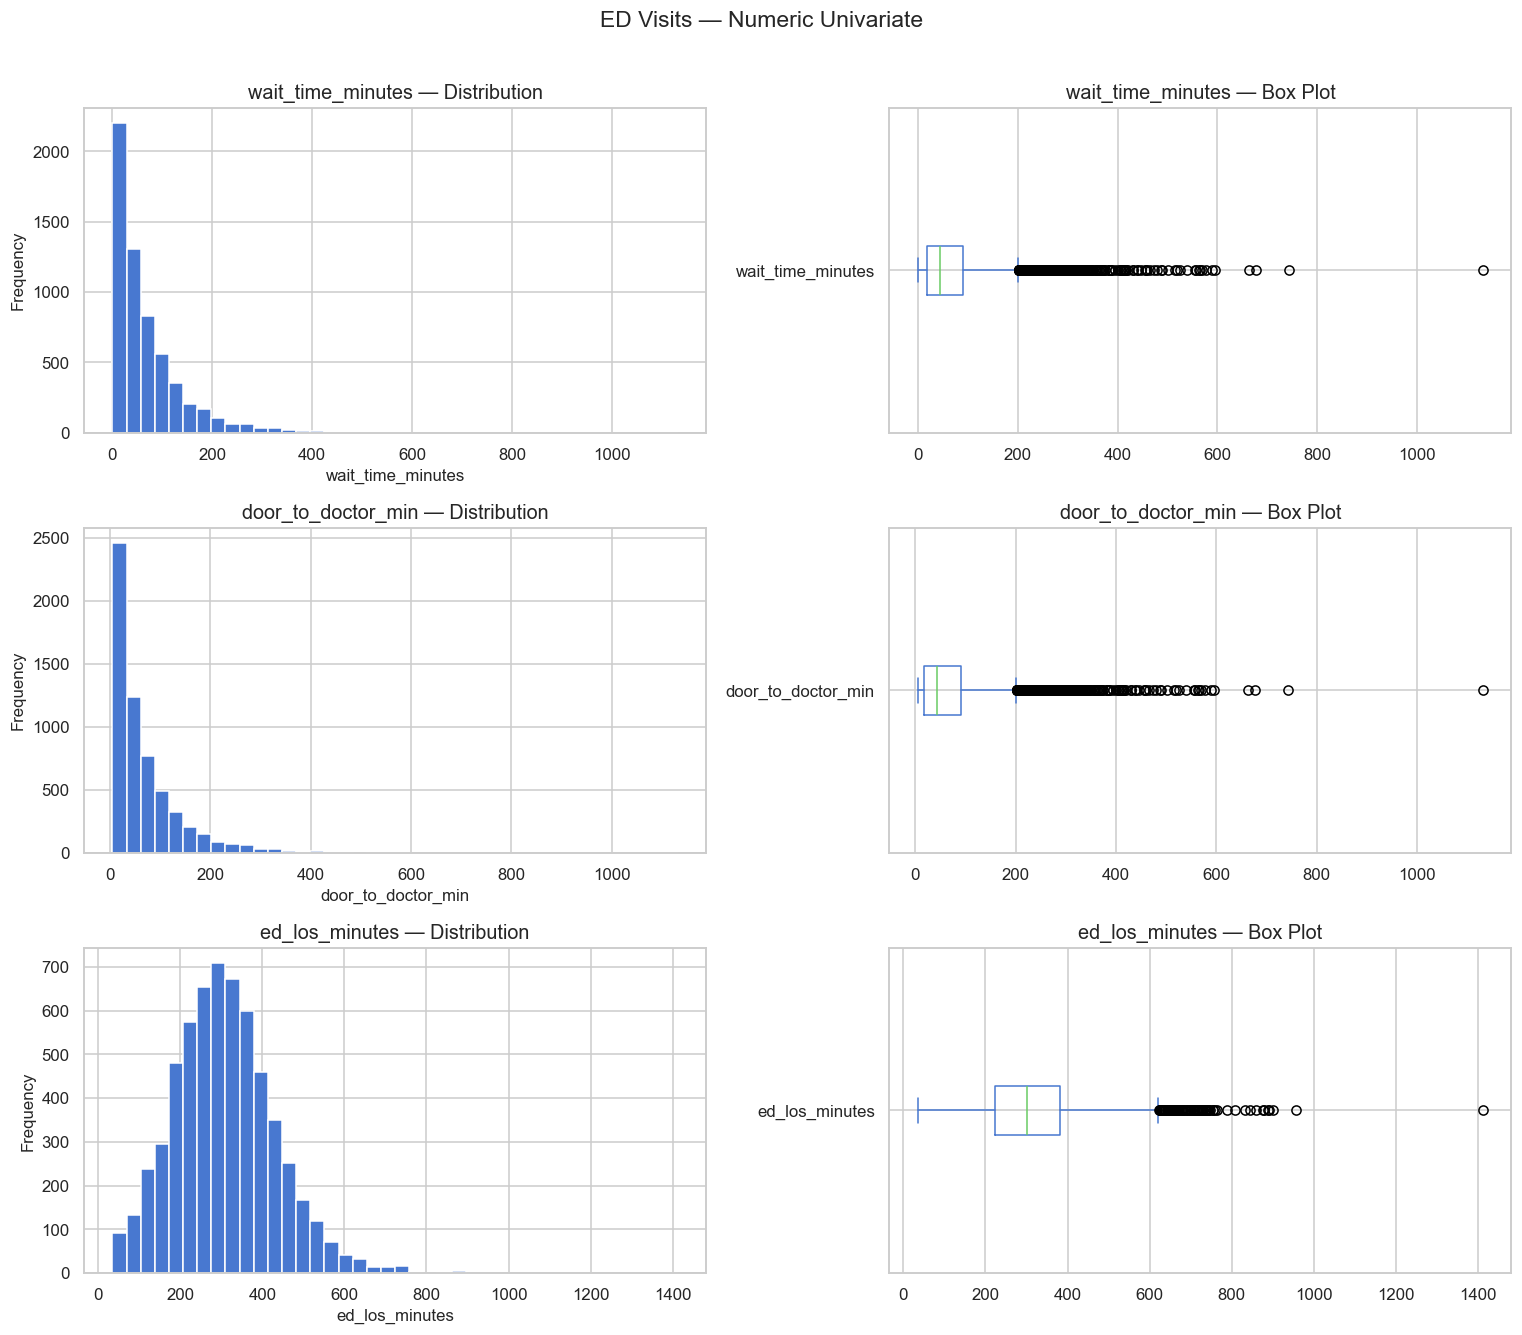

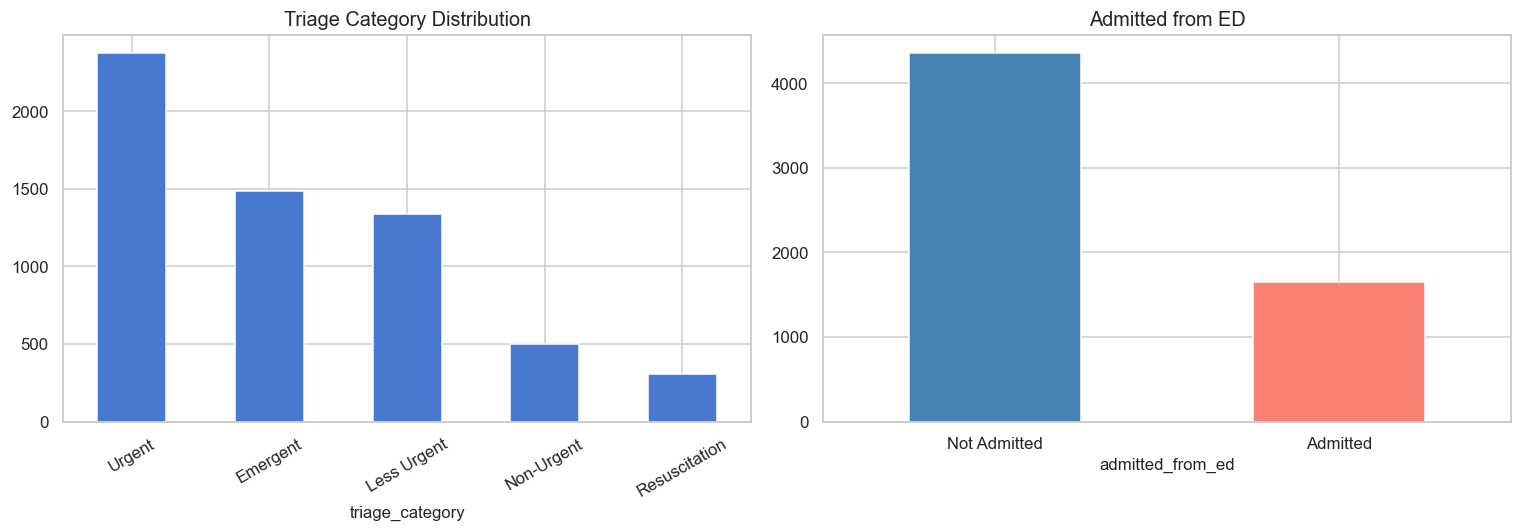

In [39]:
num_cols_ed = ['wait_time_minutes', 'door_to_doctor_min', 'ed_los_minutes']
plot_numeric_univariate(df_edvisit, num_cols_ed, 'ED Visits — Numeric Univariate')

# Triage category & admitted from ED
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_edvisit['triage_category'].value_counts().plot.bar(ax=axes[0], edgecolor='white')
axes[0].set_title('Triage Category Distribution')
axes[0].tick_params(axis='x', rotation=30)

df_edvisit['admitted_from_ed'].value_counts().plot.bar(ax=axes[1], edgecolor='white',
                                                         color=['steelblue', 'salmon'])
axes[1].set_title('Admitted from ED')
axes[1].set_xticklabels(['Not Admitted', 'Admitted'], rotation=0)
plt.tight_layout()
plt.show()

### 4b. ED Visits — Bivariate Analysis

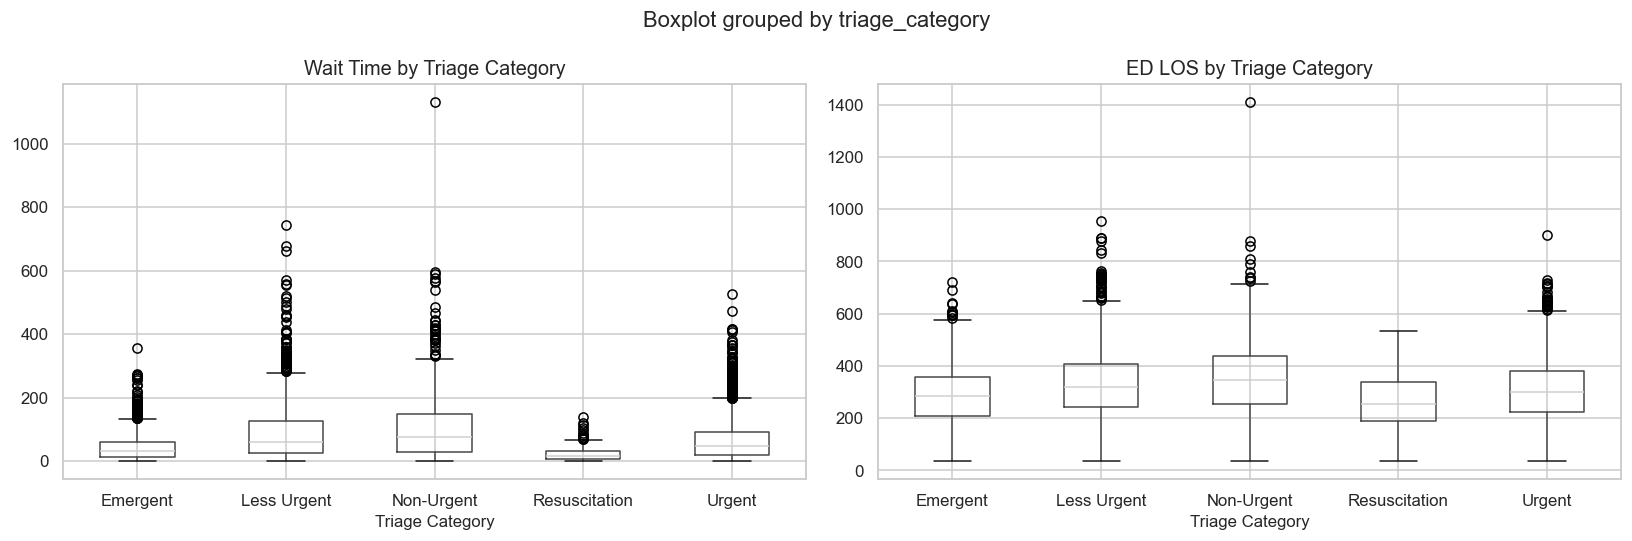

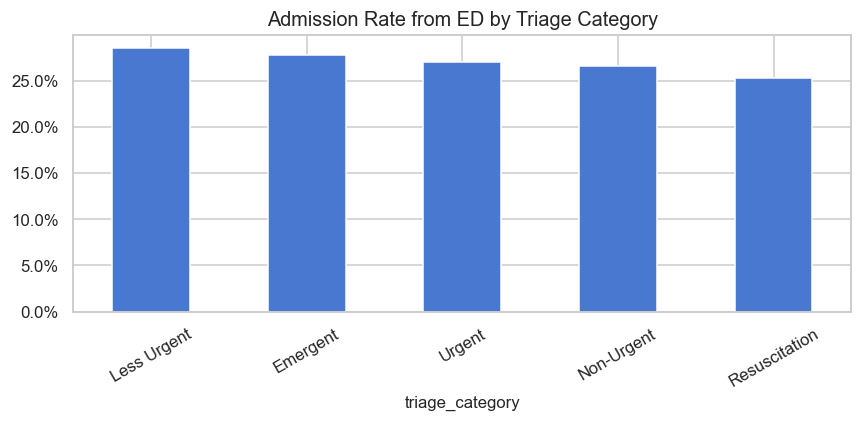

In [41]:
# Wait time and LOS by triage category
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_edvisit.boxplot(column='wait_time_minutes', by='triage_category', ax=axes[0])
axes[0].set_title('Wait Time by Triage Category')
axes[0].set_xlabel('Triage Category')
plt.suptitle('')

df_edvisit.boxplot(column='ed_los_minutes', by='triage_category', ax=axes[1])
axes[1].set_title('ED LOS by Triage Category')
axes[1].set_xlabel('Triage Category')
plt.tight_layout()
plt.show()

# Admission rate by triage category
adm_rate = df_edvisit.groupby('triage_category')['admitted_from_ed'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
adm_rate.plot.bar(ax=ax, edgecolor='white')
ax.set_title('Admission Rate from ED by Triage Category')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 4c. ED Visits — Multivariate Analysis

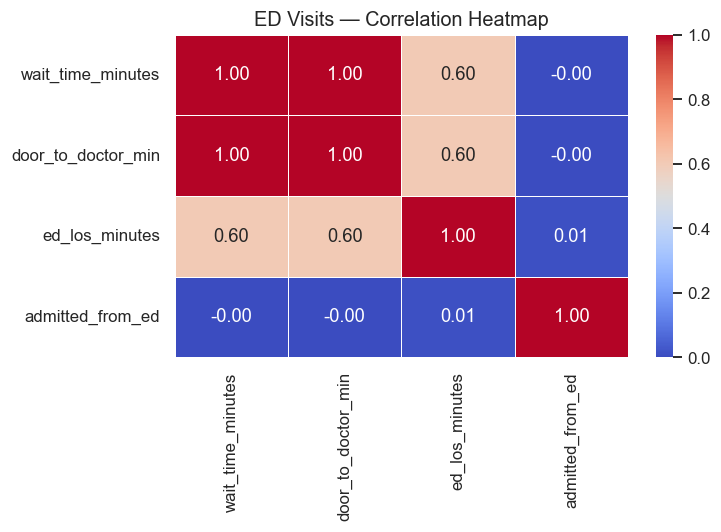

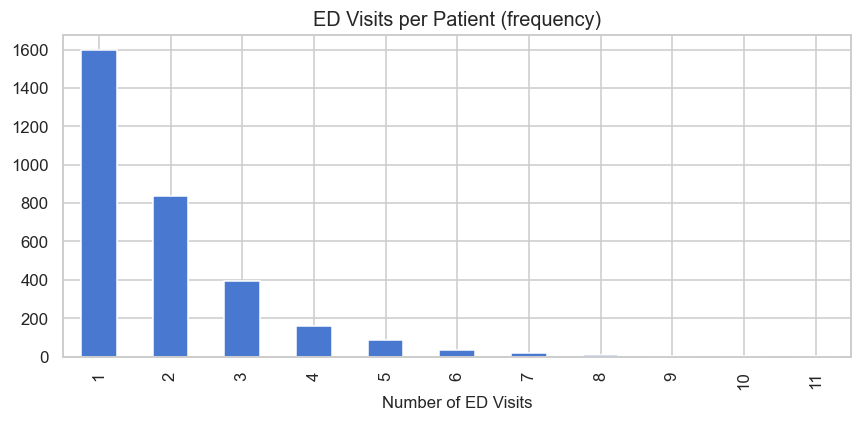

count    3143.00
mean        1.91
std         1.29
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        11.00
Name: num_ed_visits, dtype: float64


In [42]:
# Correlation heatmap
ed_num = df_edvisit[['wait_time_minutes', 'door_to_doctor_min', 'ed_los_minutes', 'admitted_from_ed']]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(ed_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('ED Visits — Correlation Heatmap')
plt.tight_layout()
plt.show()

# ED visits per patient (frequency)
ed_per_patient = df_edvisit.groupby('patient_id').size().reset_index(name='num_ed_visits')
fig, ax = plt.subplots(figsize=(8, 4))
ed_per_patient['num_ed_visits'].value_counts().sort_index().plot.bar(ax=ax, edgecolor='white')
ax.set_title('ED Visits per Patient (frequency)')
ax.set_xlabel('Number of ED Visits')
plt.tight_layout()
plt.show()
print(ed_per_patient['num_ed_visits'].describe().round(2))

---
## 5. Medications
**Key columns:** `medication_id`, `admission_id`, `drug_class`, `is_high_alert`, `start_datetime`, `end_datetime`

In [43]:
missing_summary(df_med, 'medications')
df_med.describe().T


  MEDICATIONS — shape: (51112, 12)
  No missing values.

  Duplicate rows: 0
medication_id     object
admission_id      object
patient_id        object
drug_name         object
dose              object
route             object
frequency         object
drug_class        object
start_datetime    object
end_datetime      object
prescribed_by     object
is_high_alert      int64


,count,mean,std,min,25%,50%,75%,max
is_high_alert,51112.0,0.164638,0.370858,0.0,0.0,0.0,0.0,1.0


### 5a. Medications — Univariate Analysis

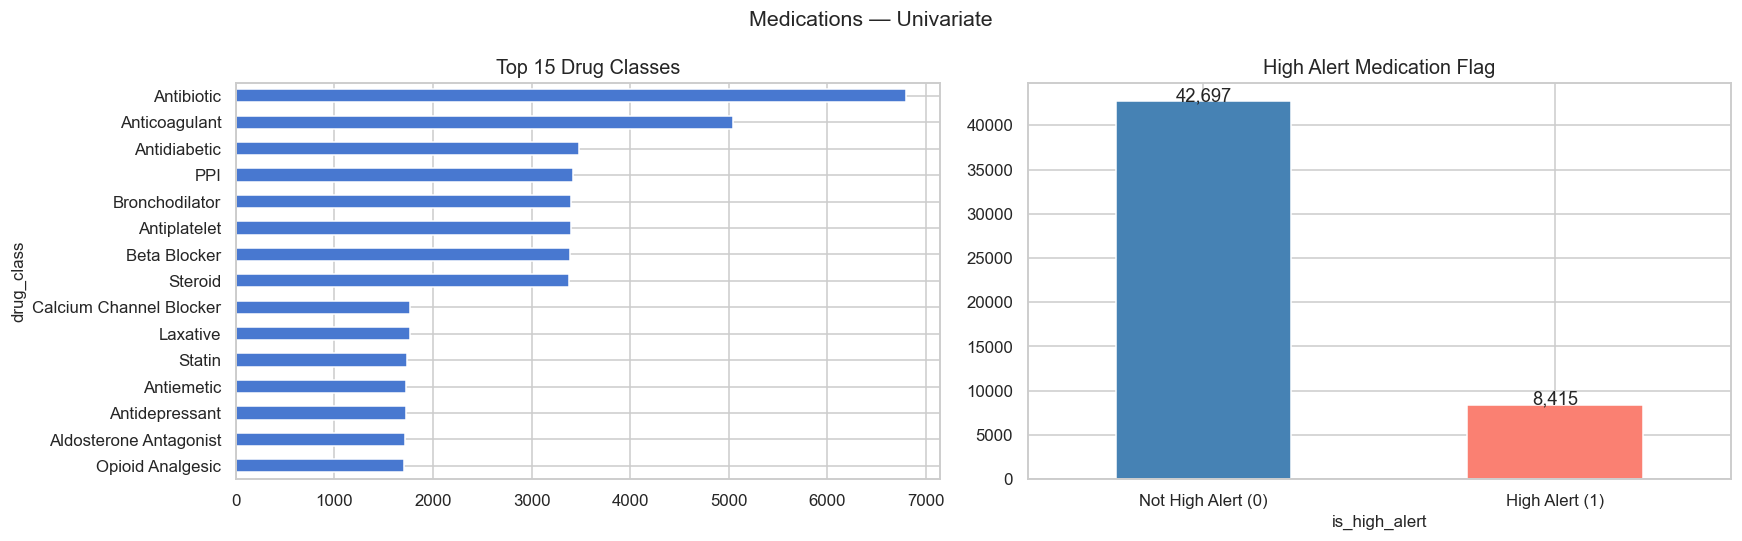

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top drug classes
df_med['drug_class'].value_counts().head(15).plot.barh(ax=axes[0])
axes[0].set_title('Top 15 Drug Classes')
axes[0].invert_yaxis()

# High alert medications
df_med['is_high_alert'].value_counts().plot.bar(ax=axes[1], edgecolor='white',
                                                  color=['steelblue', 'salmon'])
axes[1].set_title('High Alert Medication Flag')
axes[1].set_xticklabels(['Not High Alert (0)', 'High Alert (1)'], rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()+10), ha='center')

fig.suptitle('Medications — Univariate', fontsize=14)
plt.tight_layout()
plt.show()

### 5b. Medications — Bivariate Analysis

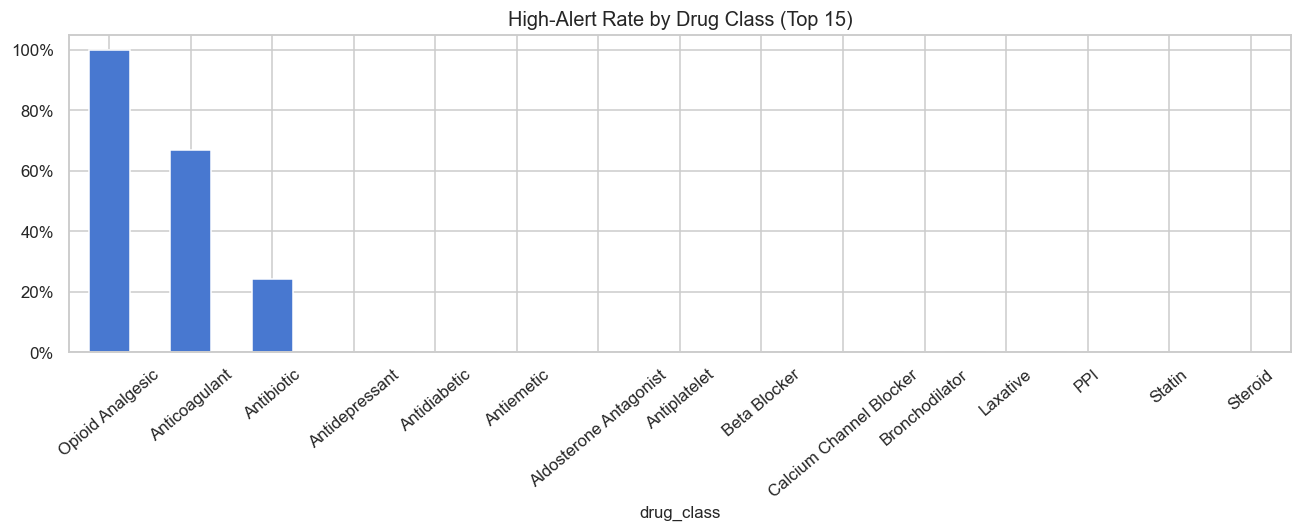

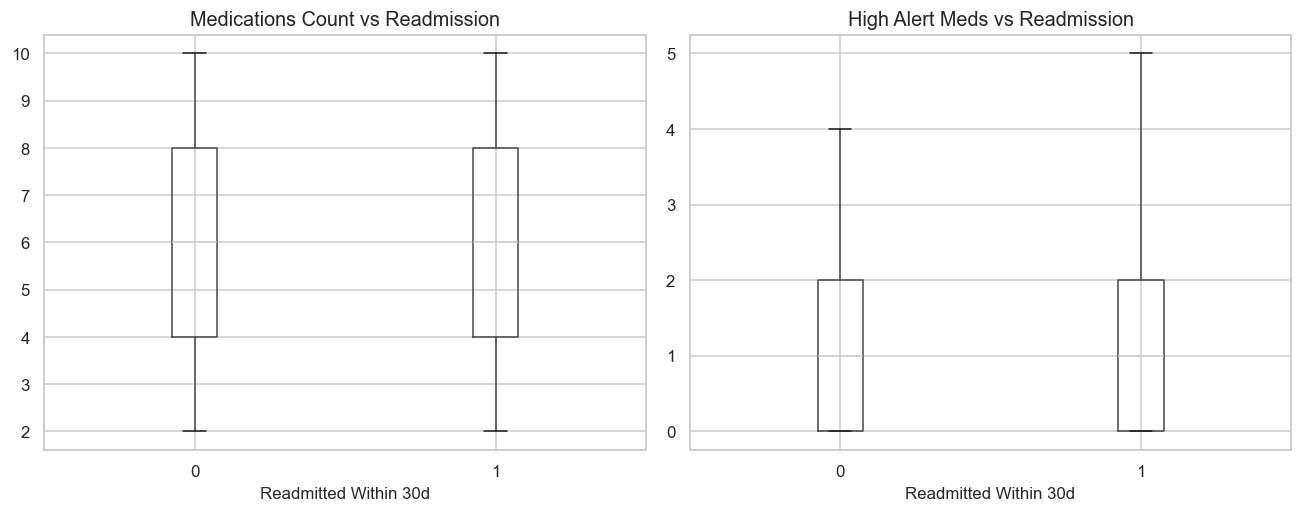

In [46]:
# High-alert rate by drug class (top 15 classes)
top_classes = df_med['drug_class'].value_counts().head(15).index
med_top = df_med[df_med['drug_class'].isin(top_classes)]
ha_rate = med_top.groupby('drug_class')['is_high_alert'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ha_rate.plot.bar(ax=ax, edgecolor='white')
ax.set_title('High-Alert Rate by Drug Class (Top 15)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

# Medications per admission vs readmission
med_agg_biv = df_med.groupby('admission_id').agg(
    num_medications=('medication_id', 'count'),
    num_high_alert=('is_high_alert', 'sum'),
).reset_index()
merged_med = med_agg_biv.merge(df_admin[['admission_id', 'readmitted_within_30d']], on='admission_id', how='left')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
merged_med.boxplot(column='num_medications', by='readmitted_within_30d', ax=axes[0])
axes[0].set_title('Medications Count vs Readmission')
axes[0].set_xlabel('Readmitted Within 30d')
merged_med.boxplot(column='num_high_alert', by='readmitted_within_30d', ax=axes[1])
axes[1].set_title('High Alert Meds vs Readmission')
axes[1].set_xlabel('Readmitted Within 30d')
plt.suptitle('')
plt.tight_layout()
plt.show()

### 5c. Medications — Multivariate Analysis

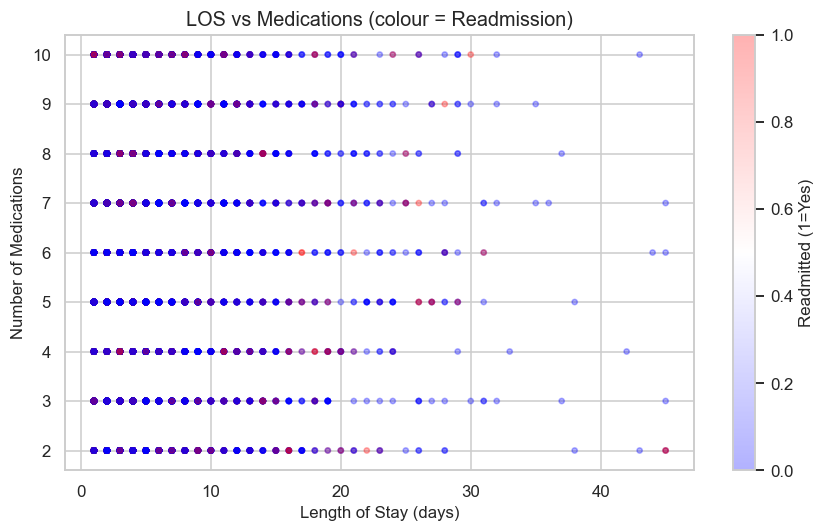

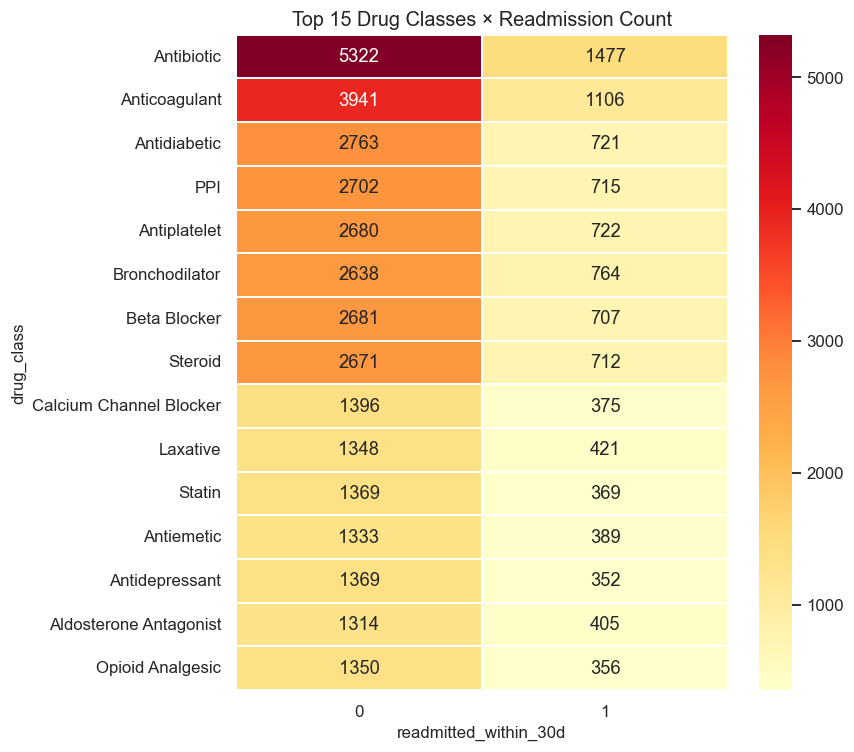

In [47]:
# Medication count vs LOS vs readmission
merged_med_los = merged_med.merge(
    df_admin[['admission_id', 'length_of_stay_days']], on='admission_id', how='left'
)
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    merged_med_los['length_of_stay_days'], merged_med_los['num_medications'],
    c=merged_med_los['readmitted_within_30d'], cmap='bwr', alpha=0.3, s=12
)
plt.colorbar(scatter, ax=ax, label='Readmitted (1=Yes)')
ax.set_xlabel('Length of Stay (days)')
ax.set_ylabel('Number of Medications')
ax.set_title('LOS vs Medications (colour = Readmission)')
plt.tight_layout()
plt.show()

# Drug class × readmission heatmap
med_adm = df_med.merge(df_admin[['admission_id', 'readmitted_within_30d']], on='admission_id', how='left')
pivot = med_adm.groupby(['drug_class', 'readmitted_within_30d']).size().unstack(fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).nlargest(15).index]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_title('Top 15 Drug Classes × Readmission Count')
plt.tight_layout()
plt.show()

---
## 6. Vitals
**Key columns:** `vital_id`, `admission_id`, `systolic_bp`, `diastolic_bp`, `heart_rate`, `respiratory_rate`, `temperature_c`, `spo2_percent`, `gcs_score`, `news2_score`, `pain_score`, `weight_kg`, `height_cm`

In [48]:
missing_summary(df_vitals, 'vitals')
df_vitals.describe().T


  VITALS — shape: (41382, 15)
  No missing values.

  Duplicate rows: 0
vital_id             object
admission_id         object
patient_id           object
measured_at          object
systolic_bp         float64
diastolic_bp        float64
heart_rate          float64
respiratory_rate    float64
temperature_c       float64
spo2_percent        float64
gcs_score             int64
news2_score           int64
pain_score            int64
weight_kg           float64
height_cm           float64


,count,mean,std,min,25%,50%,75%,max
systolic_bp,41382.0,127.979182,19.921467,70.0,114.6,127.9,141.5,210.0
diastolic_bp,41382.0,78.095991,14.038697,40.0,68.6,78.1,87.5,130.0
heart_rate,41382.0,81.916389,16.087537,35.0,71.0,82.0,93.0,159.0
respiratory_rate,41382.0,16.989971,3.976669,8.0,14.0,17.0,20.0,35.0
temperature_c,41382.0,37.097973,0.597032,34.8,36.7,37.1,37.5,39.5
spo2_percent,41382.0,96.412300,2.335968,86.4,94.8,96.5,98.2,100.0
gcs_score,41382.0,14.178773,1.264489,10.0,14.0,15.0,15.0,15.0
news2_score,41382.0,2.493717,2.054005,0.0,0.0,3.0,4.0,12.0
pain_score,41382.0,4.992364,3.168986,0.0,2.0,5.0,8.0,10.0
weight_kg,41382.0,82.100945,19.695932,40.0,68.3,81.9,95.5,168.1


### 6a. Vitals — Univariate Analysis

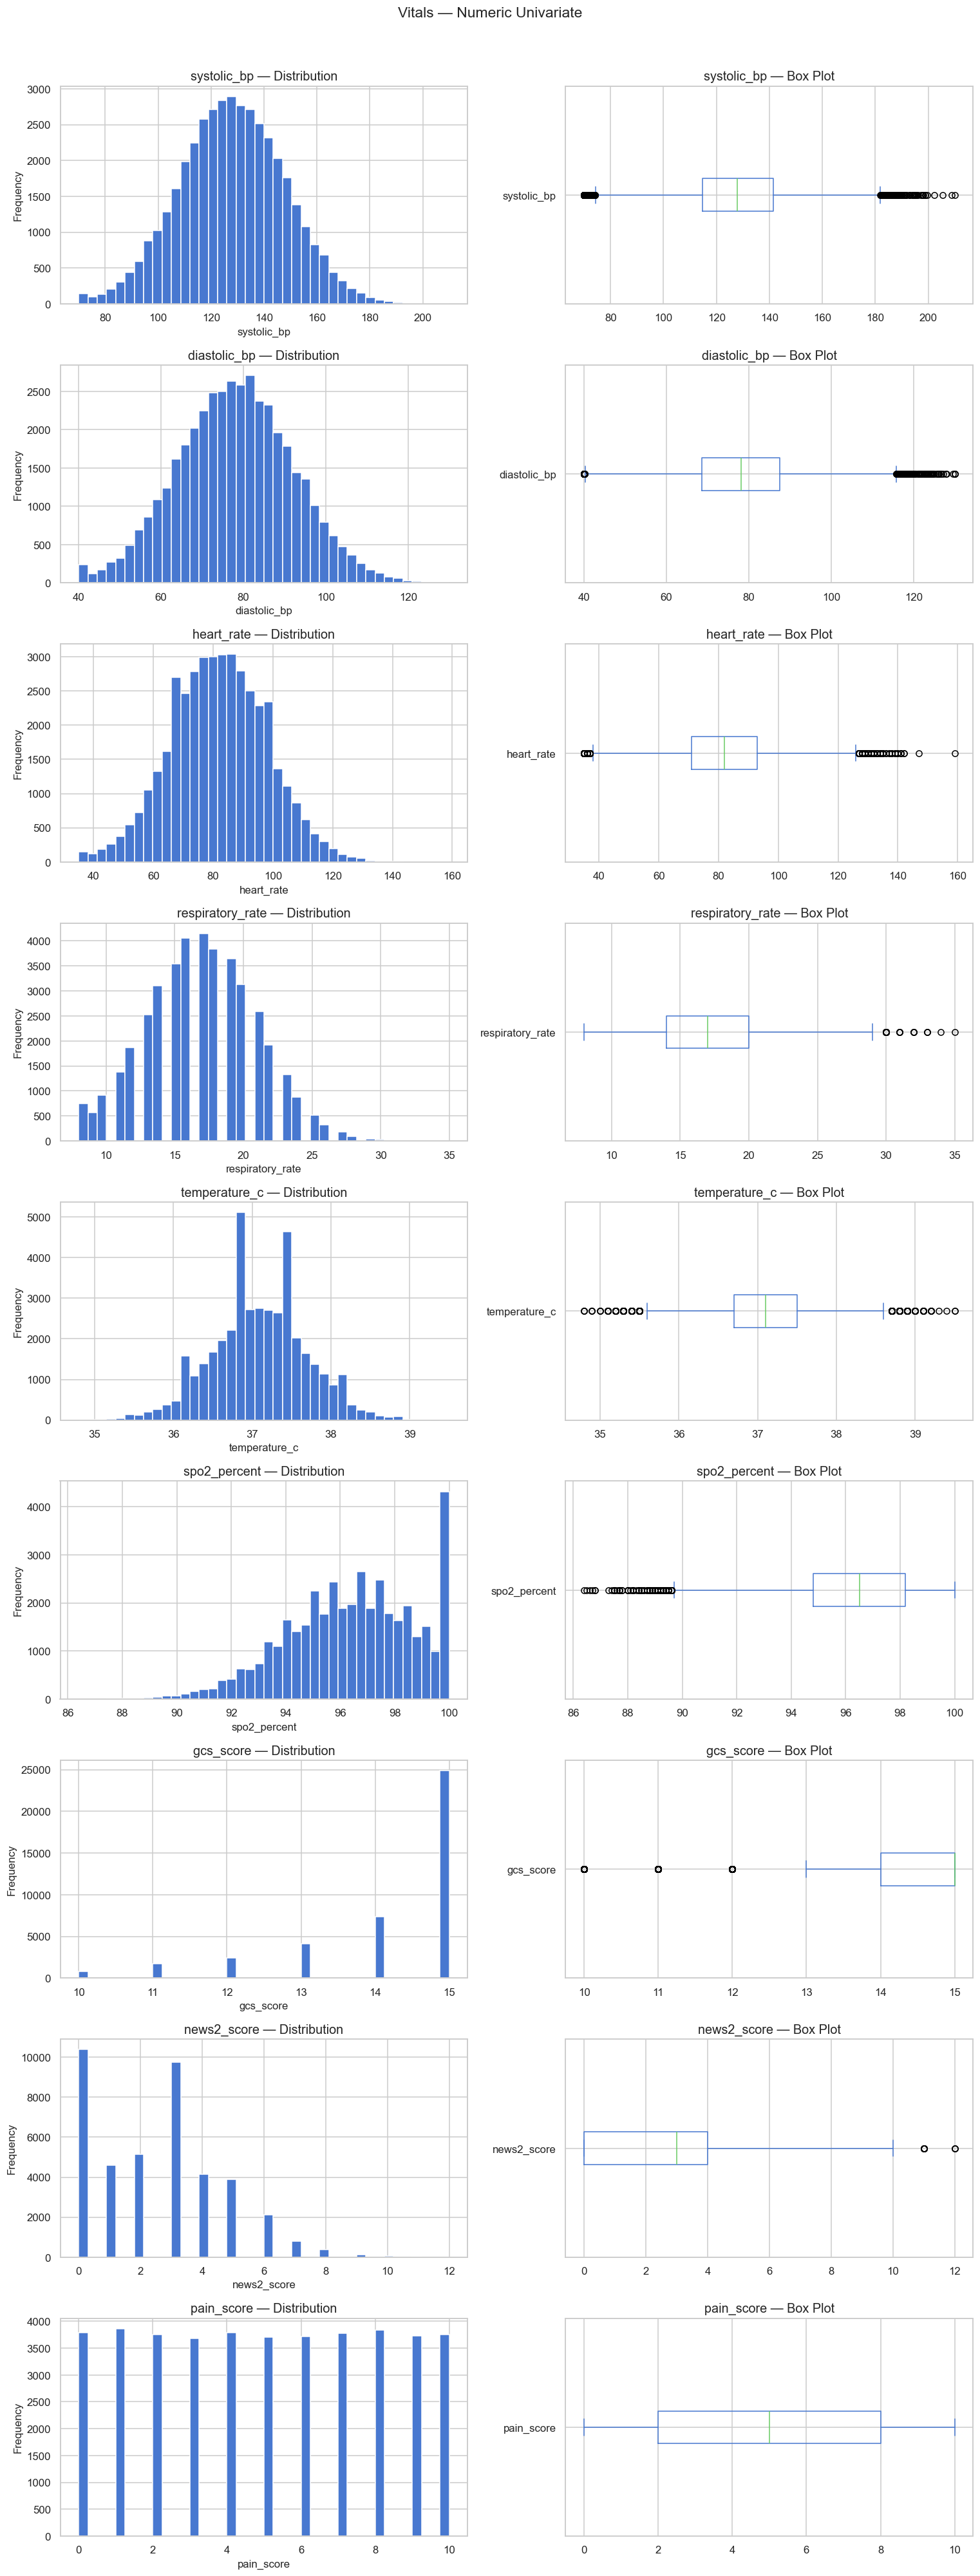

In [49]:
vital_num_cols = ['systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate',
                  'temperature_c', 'spo2_percent', 'gcs_score', 'news2_score', 'pain_score']
plot_numeric_univariate(df_vitals, vital_num_cols, 'Vitals — Numeric Univariate')

### 6b. Vitals — Bivariate Analysis (mean vitals vs readmission)

Mean vitals by readmission status:
readmitted_within_30d       0       1
systolic_bp            128.08  127.71
diastolic_bp            78.11   78.14
heart_rate              81.90   82.03
respiratory_rate        17.01   16.98
temperature_c           37.10   37.09
spo2_percent            96.41   96.42
gcs_score               14.18   14.17
news2_score              2.50    2.52
pain_score               5.00    4.96


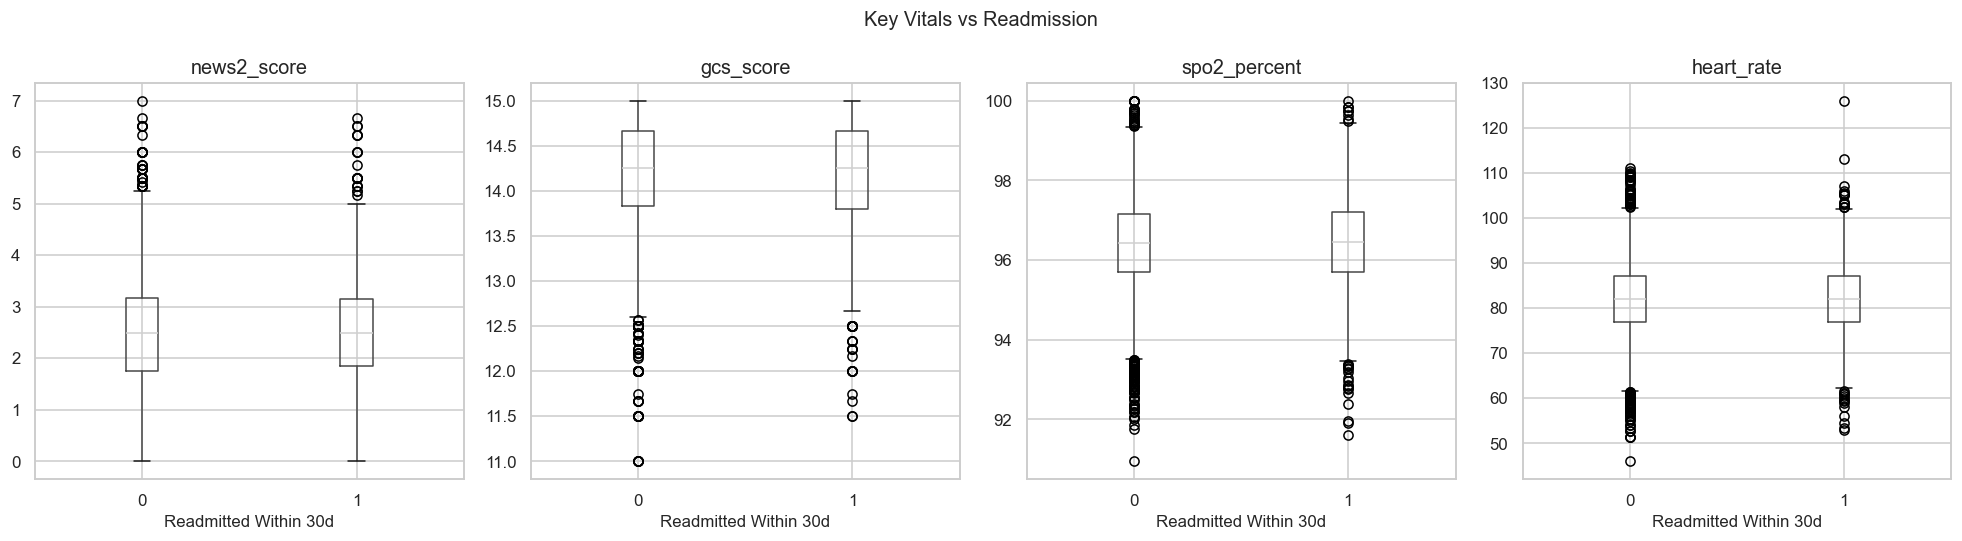

In [50]:
# Aggregate vitals per admission then join readmission label
vitals_agg_biv = df_vitals.groupby('admission_id')[vital_num_cols].mean().reset_index()
vitals_merged = vitals_agg_biv.merge(df_admin[['admission_id', 'readmitted_within_30d']], on='admission_id', how='left')

# Mean vital values by readmission status
print("Mean vitals by readmission status:")
print(vitals_merged.groupby('readmitted_within_30d')[vital_num_cols].mean().round(2).T)

# Box plots for key vitals vs readmission
key_vitals = ['news2_score', 'gcs_score', 'spo2_percent', 'heart_rate']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, key_vitals):
    vitals_merged.boxplot(column=col, by='readmitted_within_30d', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Readmitted Within 30d')
fig.suptitle('Key Vitals vs Readmission', fontsize=13)
plt.tight_layout()
plt.show()

### 6c. Vitals — Multivariate Analysis

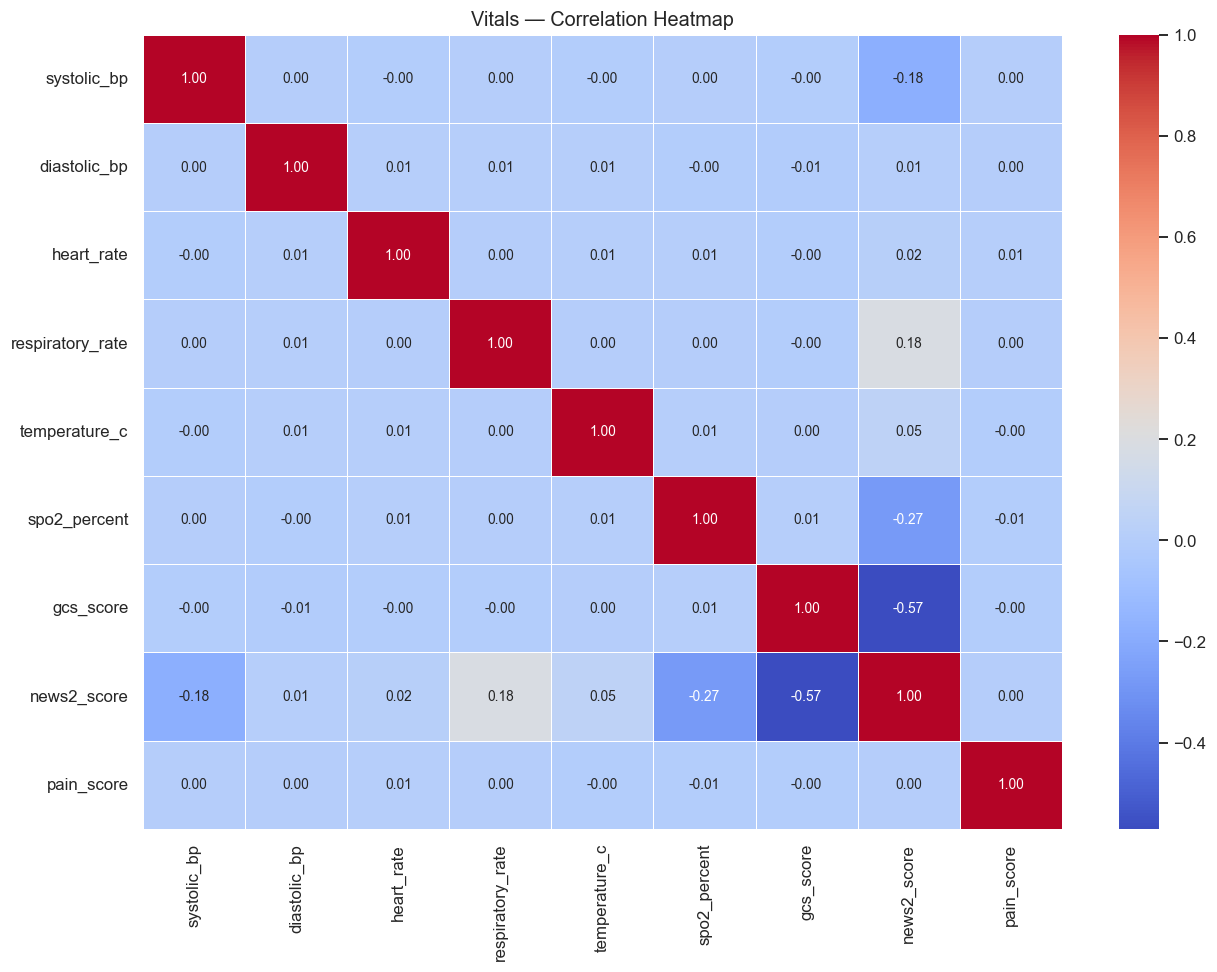

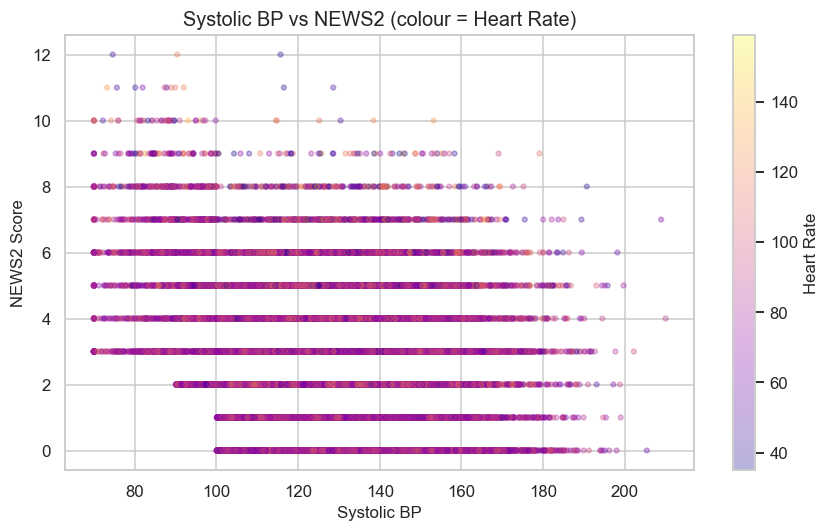

In [51]:
# Correlation heatmap across all vital signs
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    df_vitals[vital_num_cols].corr(), annot=True, fmt='.2f',
    cmap='coolwarm', ax=ax, linewidths=0.4, annot_kws={'size': 9}
)
ax.set_title('Vitals — Correlation Heatmap')
plt.tight_layout()
plt.show()

# NEWS2 score vs systolic BP coloured by heart rate
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    df_vitals['systolic_bp'].dropna(), df_vitals['news2_score'].dropna(),
    c=df_vitals.dropna(subset=['systolic_bp', 'news2_score'])['heart_rate'],
    cmap='plasma', alpha=0.3, s=10
)
plt.colorbar(sc, ax=ax, label='Heart Rate')
ax.set_xlabel('Systolic BP')
ax.set_ylabel('NEWS2 Score')
ax.set_title('Systolic BP vs NEWS2 (colour = Heart Rate)')
plt.tight_layout()
plt.show()

---
## 7. Readmissions
**Key columns:** `readmission_id`, `patient_id`, `original_discharge_date`, `readmission_date`, `days_to_readmission`, `planned_readmission`, `same_diagnosis`

In [52]:
missing_summary(df_readmission, 'readmissions')
df_readmission.describe().T


  READMISSIONS — shape: (1813, 11)
  No missing values.

  Duplicate rows: 0
readmission_id                  object
original_admission_id           object
patient_id                      object
original_discharge_date         object
readmission_date                object
days_to_readmission              int64
readmission_type                object
readmission_reason              object
same_diagnosis                   int64
planned_readmission              int64
avoided_if_discharged_better     int64


,count,mean,std,min,25%,50%,75%,max
days_to_readmission,1813.0,15.728627,8.715154,1.0,8.0,16.0,23.0,30.0
same_diagnosis,1813.0,0.509101,0.500055,0.0,0.0,1.0,1.0,1.0
planned_readmission,1813.0,0.124104,0.329791,0.0,0.0,0.0,0.0,1.0
avoided_if_discharged_better,1813.0,0.511307,0.500010,0.0,0.0,1.0,1.0,1.0


### 7a. Readmissions — Univariate Analysis

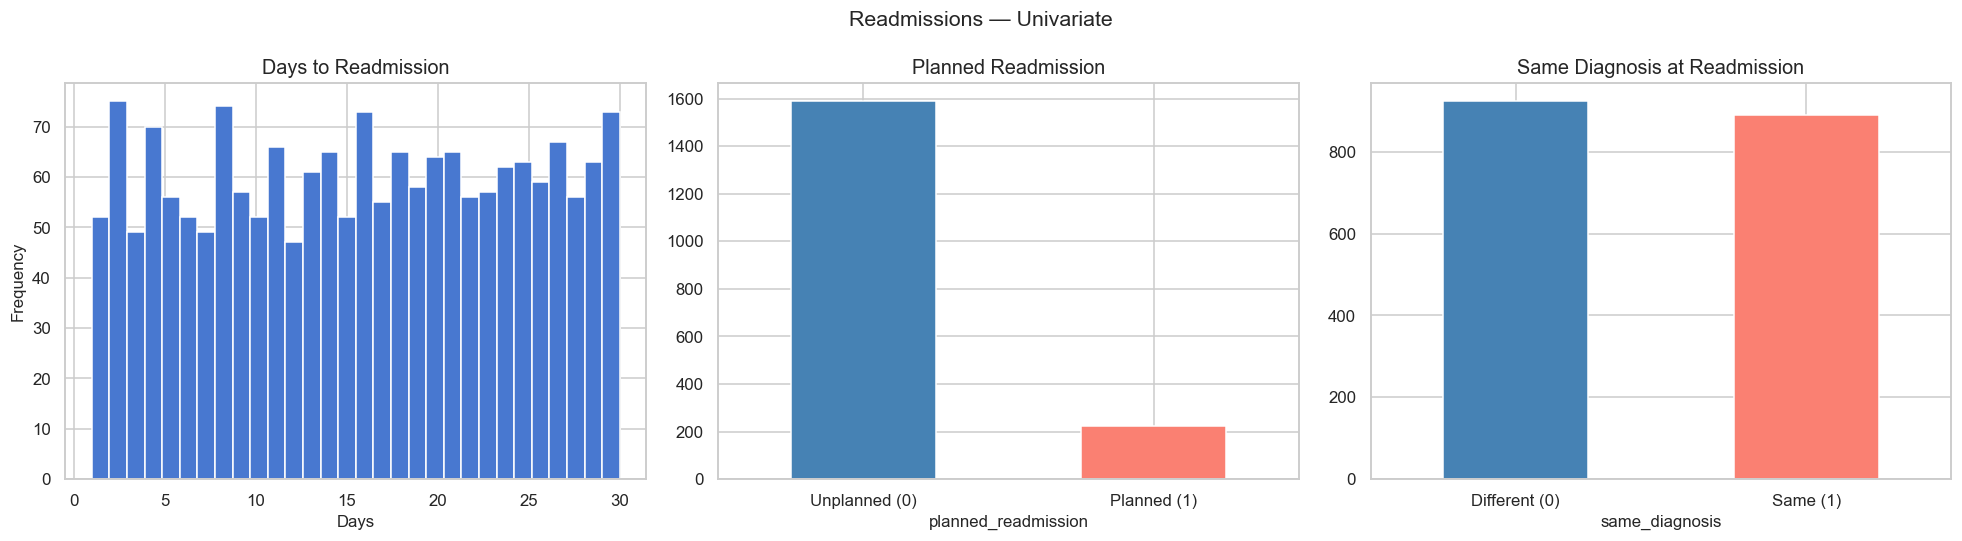

count    1813.00
mean       15.73
std         8.72
min         1.00
25%         8.00
50%        16.00
75%        23.00
max        30.00
Name: days_to_readmission, dtype: float64


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Days to readmission
df_readmission['days_to_readmission'].plot.hist(bins=30, ax=axes[0], edgecolor='white')
axes[0].set_title('Days to Readmission')
axes[0].set_xlabel('Days')

# Planned readmission
df_readmission['planned_readmission'].value_counts().plot.bar(ax=axes[1], edgecolor='white',
                                                               color=['steelblue', 'salmon'])
axes[1].set_title('Planned Readmission')
axes[1].set_xticklabels(['Unplanned (0)', 'Planned (1)'], rotation=0)

# Same diagnosis flag
df_readmission['same_diagnosis'].value_counts().plot.bar(ax=axes[2], edgecolor='white',
                                                          color=['steelblue', 'salmon'])
axes[2].set_title('Same Diagnosis at Readmission')
axes[2].set_xticklabels(['Different (0)', 'Same (1)'], rotation=0)

fig.suptitle('Readmissions — Univariate', fontsize=14)
plt.tight_layout()
plt.show()

print(df_readmission['days_to_readmission'].describe().round(2))

### 7b. Readmissions — Bivariate Analysis

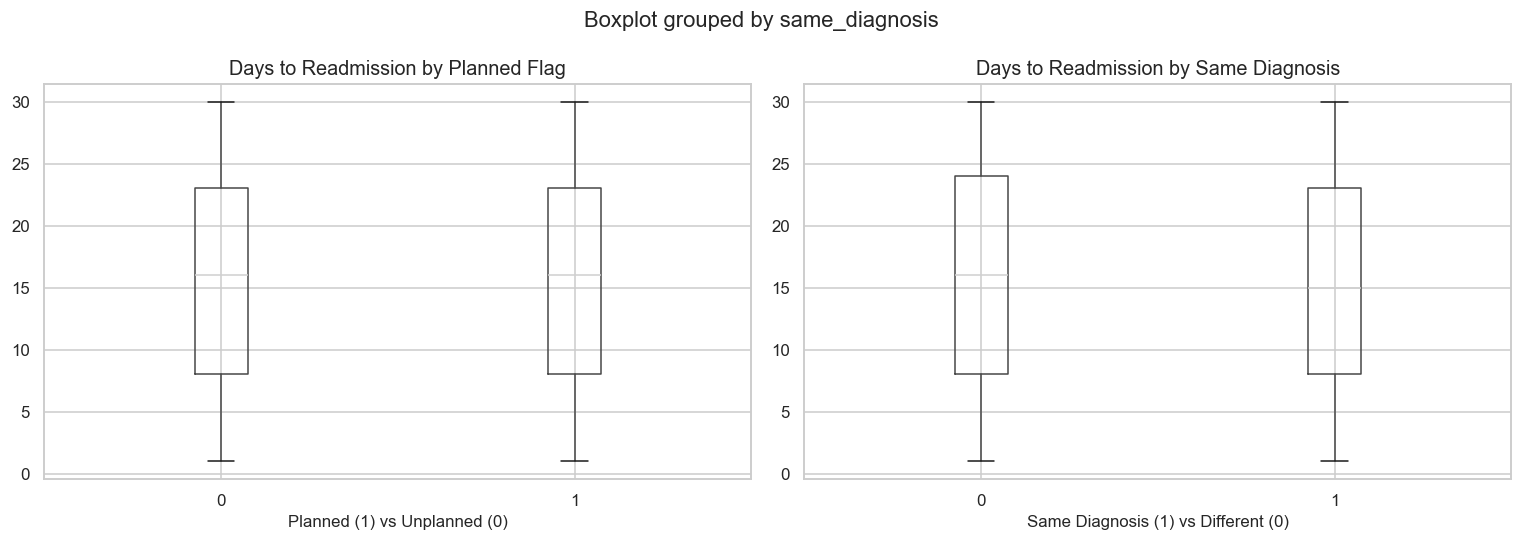

Mean days to readmission:
  By planned: {0: 15.73, 1: 15.74}
  By same_dx: {0: 15.97, 1: 15.5}


In [54]:
# Days to readmission: planned vs unplanned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_readmission.boxplot(column='days_to_readmission', by='planned_readmission', ax=axes[0])
axes[0].set_title('Days to Readmission by Planned Flag')
axes[0].set_xlabel('Planned (1) vs Unplanned (0)')
plt.suptitle('')

# Days to readmission: same vs different diagnosis
df_readmission.boxplot(column='days_to_readmission', by='same_diagnosis', ax=axes[1])
axes[1].set_title('Days to Readmission by Same Diagnosis')
axes[1].set_xlabel('Same Diagnosis (1) vs Different (0)')
plt.tight_layout()
plt.show()

print("Mean days to readmission:")
print("  By planned:", df_readmission.groupby('planned_readmission')['days_to_readmission'].mean().round(2).to_dict())
print("  By same_dx:", df_readmission.groupby('same_diagnosis')['days_to_readmission'].mean().round(2).to_dict())

### 7c. Readmissions — Multivariate Analysis

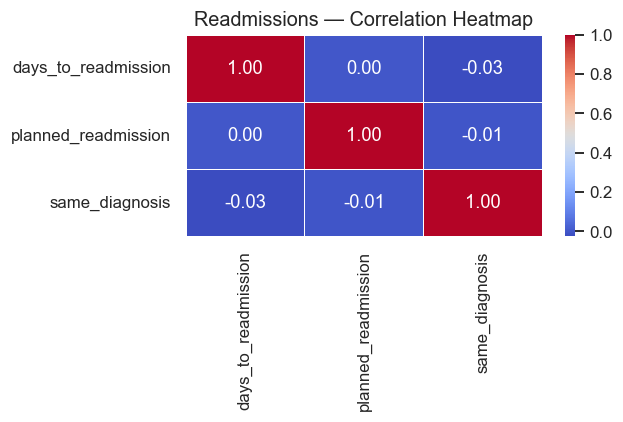

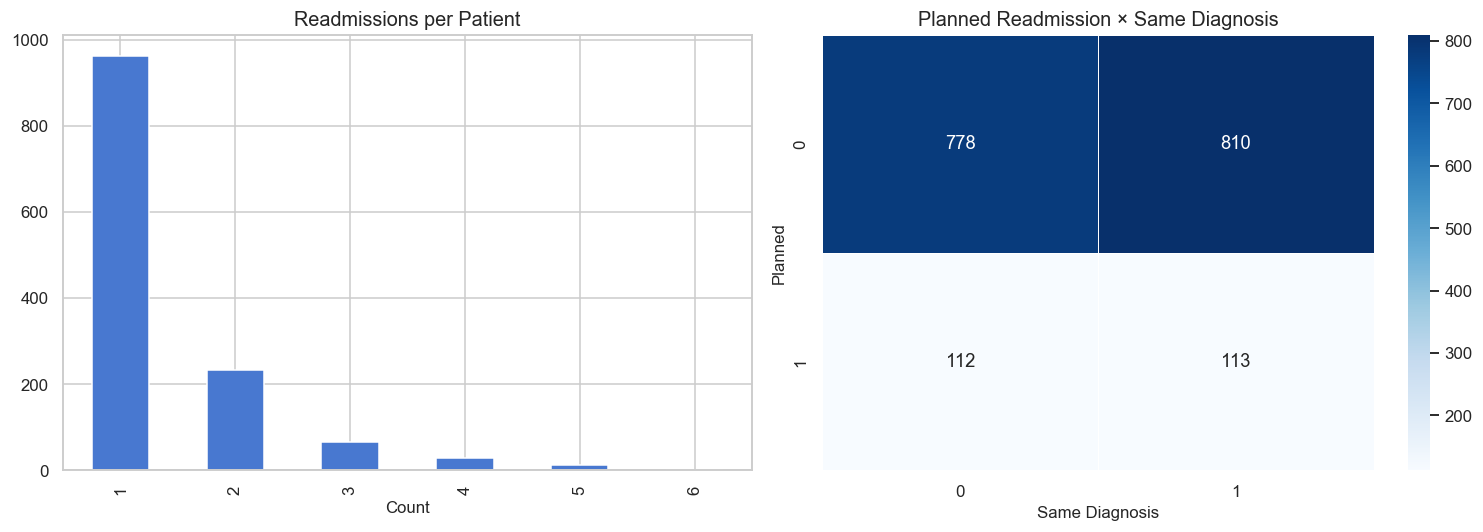

In [55]:
# Correlation heatmap
readm_num = df_readmission[['days_to_readmission', 'planned_readmission', 'same_diagnosis']]
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(readm_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Readmissions — Correlation Heatmap')
plt.tight_layout()
plt.show()

# Readmissions per patient (frequency of high utilisers)
readm_per_patient = df_readmission.groupby('patient_id').size().reset_index(name='num_readmissions')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
readm_per_patient['num_readmissions'].value_counts().sort_index().plot.bar(ax=axes[0], edgecolor='white')
axes[0].set_title('Readmissions per Patient')
axes[0].set_xlabel('Count')

# Cross-tab: planned vs same_diagnosis
ct = pd.crosstab(df_readmission['planned_readmission'], df_readmission['same_diagnosis'],
                 rownames=['Planned'], colnames=['Same Diagnosis'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[1], linewidths=0.5)
axes[1].set_title('Planned Readmission × Same Diagnosis')
plt.tight_layout()
plt.show()